# Objective and estimands

This notebook evaluates temporal transport of the frozen Cox model for **first documented readmission after discharge**. The model is fitted once in each of the five imputed 80% development samples and applied without updating to the corresponding internal holdout and to new C1 patients entering treatment from 2021 onward.

The external outcome is evaluated separately from mortality. Individual death dates are unavailable after 2020 and are therefore **not used to censor external follow-up**. The external estimand is time to first documented readmission in the available treatment registry, with administrative censoring at the last date on which a new admission can be observed. This measurement difference from the internally validated cause-specific analysis is stated explicitly and will be quantified in a supplementary death-masking sensitivity after reconstruction from the pre-censoring source layer.

Performance is assessed at 6, 12, and 36 months using the same Uno weighting estimator as `prediction23`. Because the frozen Cox model is stratified, the primary ranking score is the pooled absolute risk at each horizon, which incorporates the original stratum-specific baseline hazards. A concordance restricted to comparable pairs within the ten baseline strata is retained as a supplementary diagnostic. Calibration slope, expected-to-observed ratio, ICI, point Brier score, and IBS are also reported.

## Decisions fixed before performance estimation

- Use the final parsimonious readmission formula from `prediction23_converted_mod`.
- Fit and preserve all five development-imputation models.
- Use one external cohort for all horizons. Horizon-specific risk sets and IPCW weights change, but `ymax` does not define a new target cohort.
- Use 20 December 2024 as the outcome-ascertainment cutoff because this is the last observed **admission**, whereas 28 May 2025 is only the last discharge.
- Report SMDs for the complete external analysis cohort. Horizon-specific complete-follow-up SMDs are supplementary diagnostics, not the primary transport comparison.
- Use horizon-specific absolute risk for the primary Uno C. A raw linear predictor has no common origin across the baseline-hazard strata and must not be compared globally.
- Retain LP-based Uno C restricted to within-stratum pairs as a supplementary diagnostic.
- Use Riley et al. (2022) simulations and bootstrap precision as the formal information assessment.
- Report Kish-type effective information for IPCW weights only as a diagnostic. The algebra is not survey-specific, but it is not a formal sample-size calculation here.
- Report events per coefficient parameter descriptively. No EPV threshold is used because the prediction model is frozen rather than developed in the validation data.
- Do not use `pmsampsize`, which targets prediction-model development. The current `pmvalsampsize` implementation does not support survival outcomes.
- Do not use matching, treatment weighting, C5, or external decision-curve analysis.

In [1]:
#| label: setup
#| results: hold

required_packages <- c(
  "survival", "dplyr", "stringr", "stringi", "lubridate",
  "ggplot2", "scales", "knitr", "tidyr", "purrr", "patchwork"
)
missing_packages <- required_packages[
  !vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)
]
if (length(missing_packages)) {
  stop(
    "Required packages are missing. Install them outside this analysis: ",
    paste(missing_packages, collapse = ", "),
    call. = FALSE
  )
}

suppressPackageStartupMessages({
  library(survival)
  library(dplyr)
  library(ggplot2)
})
options(stringsAsFactors = FALSE, width = 140)

Sys.setenv(PRED26_RUN_MODE = "full")

Warning messages:
1: package ‘dplyr’ was built under R version 4.4.3 
2: package ‘ggplot2’ was built under R version 4.4.3 


In [ ]:
#| label: configuration

# ---- Fixed analysis constants ----
SEED <- 2125L                                     # Master random seed for reproducible bootstrap and Riley simulations
HORIZONS <- c(6, 12, 36)                          # Prediction horizons in months for readmission risk
EXTERNAL_START <- as.Date("2021-01-01")           # First admission date for the external validation cohort
DEVELOPMENT_START <- as.Date("2010-01-01")        # Start of the original model-development period
DEVELOPMENT_END <- as.Date("2020-12-31")          # End of the original model-development period
READMISSION_CUTOFF <- as.Date("2024-12-20")       # Last date on which a new admission can be observed

# ---- Run mode selection ----
# RUN_MODE is read from the environment variable PRED26_RUN_MODE.
# Allowed values: "smoke" (fast test run) or "full" (final run with full precision).
RUN_MODE <- tolower(Sys.getenv("PRED26_RUN_MODE", "smoke"))
if (!RUN_MODE %in% c("smoke", "full")) stop("PRED26_RUN_MODE must be 'smoke' or 'full'.")

# Set computational intensity based on run mode:
# - smoke: small numbers for quick checks
# - full: numbers used for the final, manuscript-ready results
B_BOOT <- if (RUN_MODE == "full") 1000L else 20L        # Bootstrap replicates for confidence intervals
B_RILEY <- if (RUN_MODE == "full") 500L else 10L        # Monte-Carlo simulations for Riley precision audit
GRID_STEP_MONTHS <- if (RUN_MODE == "full") 0.25 else 1 # Grid resolution (months) for calibration/Brier/IBS curves
OFFICIAL_RUN <- RUN_MODE == "full"                      # Logical flag used later to name outputs and print status

# ---- Model metadata ----
MODEL_COEFFICIENT_PARAMETERS <- 26L   # Number of estimated coefficients in the frozen Cox model
MODEL_SOURCE_PREDICTORS <- 18L        # Number of original predictor variables before dummy expansion

# ---- Locate the project root ----
# The function searches a list of likely locations for the SISTRAT project
# by checking for the presence of a known input file.
find_project_root <- function() {
  candidates <- unique(c(
    Sys.getenv("SISTRAT_PROJECT_ROOT", unset = NA_character_),  # Optional user-provided path
    "G:/My Drive/Alvacast/SISTRAT 2023",                         # Expected Google Drive path
    getwd(), dirname(getwd())                                    # Current or parent directory
  ))
  candidates <- candidates[!is.na(candidates) & nzchar(candidates)]  # Remove missing/empty candidates

  for (candidate in candidates) {
    candidate <- normalizePath(candidate, winslash = "/", mustWork = FALSE)
    marker <- file.path(candidate, "data", "20241015_out", "251001_c1_1025_df_prev1y.rds")
    if (file.exists(marker)) {
      return(candidate)  # Return the first candidate that contains the expected data file
    }
  }
  stop("Could not locate the SISTRAT project. Set SISTRAT_PROJECT_ROOT.", call. = FALSE)
}

PROJECT_ROOT <- find_project_root()  # Resolved absolute path to the project root
INPUT_DIR <- file.path(PROJECT_ROOT, "data", "20241015_out", "_val_inputs")  # Folder with validation input files

# ---- Define output directory ----
# Default output folder depends on run mode:
#   full          -> .../pred26_outputs/full/
#   smoke         -> .../pred26_outputs/tentative_smoke/
# This can be overridden by setting the PRED26_OUTPUT_DIR environment variable.
OUTPUT_DIR <- Sys.getenv(
  "PRED26_OUTPUT_DIR",
  file.path(getwd(), "pred26_outputs", if (OFFICIAL_RUN) "full" else "tentative_smoke")
)
dir.create(OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)  # Create output folder if it does not exist

# ---- Build and display run configuration table ----
config <- data.frame(
  item = c(
    "run_mode", "official_run", "bootstrap_replicates", "Riley_simulations",
    "external_start", "readmission_ascertainment_cutoff",
    "model_coefficient_parameters", "model_source_predictors",
    "project_root", "output_directory"
  ),
  value = c(
    RUN_MODE, OFFICIAL_RUN, B_BOOT, B_RILEY,
    as.character(EXTERNAL_START), as.character(READMISSION_CUTOFF),
    MODEL_COEFFICIENT_PARAMETERS, MODEL_SOURCE_PREDICTORS,
    PROJECT_ROOT, normalizePath(OUTPUT_DIR, winslash = "/", mustWork = FALSE)
  )
)
knitr::kable(config, format = "markdown", caption = "Pre-specified run configuration")



Table: Pre-specified run configuration

|item                             |value                                                      |
|:--------------------------------|:----------------------------------------------------------|
|run_mode                         |full                                                       |
|official_run                     |TRUE                                                       |
|bootstrap_replicates             |1000                                                       |
|Riley_simulations                |500                                                        |
|external_start                   |2021-01-01                                                 |
|readmission_ascertainment_cutoff |2024-12-20                                                 |
|model_coefficient_parameters     |26                                                         |
|model_source_predictors          |18                                                         

In [3]:
#| label: utilities

# Global data frame used by timed_stage() to record execution time of each stage.
stage_times <- data.frame(stage = character(), seconds = numeric())

# Execute an expression, print a stage header, and record elapsed wall-clock time.
# Returns the expression's value so it can wrap any computation.
timed_stage <- function(label, expression) {
  cat(sprintf("\n=== %s ===\n", label))            # Print stage header
  flush.console()                                  # Ensure output is shown immediately
  started <- proc.time()[["elapsed"]]              # Record start time
  value <- force(expression)                       # Force evaluation of the expression
  elapsed <- proc.time()[["elapsed"]] - started    # Compute elapsed seconds
  stage_times <<- rbind(                           # Append result to global stage_times
    stage_times,
    data.frame(stage = label, seconds = elapsed)
  )
  cat(sprintf("Completed '%s' in %.2f seconds.\n", label, elapsed))
  flush.console()
  value                                            # Return the computed value
}

# Print a progress message when i reaches evenly spaced checkpoints.
# Default every = 0.10 means messages at 10%, 20%, ..., 100%.
progress_update <- function(i, total, label, every = 0.10) {
  checkpoints <- unique(pmax(1L, round(seq(every, 1, by = every) * total)))
  if (i %in% checkpoints || i == total) {          # Print only at checkpoints or the last iteration
    cat(sprintf("[%s] %d/%d (%.0f%%)\n", label, i, total, 100 * i / total))
    flush.console()
  }
  invisible(NULL)                                  # Return nothing visible
}

# Verify that a data frame contains all required columns.
# If any are missing, stop with an informative error.
assert_columns <- function(data, columns, label = deparse(substitute(data))) {
  missing <- setdiff(columns, names(data))         # Columns requested but not present
  if (length(missing)) {
    stop(label, " is missing required columns: ", paste(missing, collapse = ", "), call. = FALSE)
  }
  invisible(TRUE)                                  # Return TRUE silently if all columns exist
}

# Print a data frame as a Markdown table with a caption.
# Returns the original data frame invisibly so it can be chained or assigned.
print_table <- function(data, caption, digits = 3) {
  print(knitr::kable(data, format = "markdown", caption = caption, digits = digits))
  invisible(data)
}

# Clamp probabilities away from 0 and 1 to avoid numerical issues
# (e.g., log(0) or division by zero in calibration calculations).
clip_probability <- function(x, epsilon = 1e-8) {
  pmin(pmax(as.numeric(x), epsilon), 1 - epsilon)
}

# Convert a vector to Date, accepting multiple common formats.
# Already-Date input is returned unchanged.
parse_date_safely <- function(x) {
  if (inherits(x, "Date")) return(x)
  as.Date(lubridate::parse_date_time(
    as.character(x),
    orders = c("dmy", "ymd", "dmY", "Ymd"),  # Accepted date formats
    quiet = TRUE,
    tz = "UTC"
  ))
}

# Standardize text: lowercase, remove diacritics, collapse extra whitespace.
# Useful for harmonizing categorical strings before recoding.
normalize_text <- function(x) {
  stringr::str_squish(stringr::str_to_lower(
    stringi::stri_trans_general(as.character(x), "Latin-ASCII")
  ))
}

# Generate bootstrap resampling indices.
# Each replicate is a vector of length n sampled with replacement.
# The global SEED is used for reproducibility.
make_bootstrap_indices <- function(n, replicates, seed = SEED) {
  set.seed(seed)
  lapply(seq_len(replicates), function(i) sample.int(n, n, replace = TRUE))
}

## Frozen model specification

The formula and all dummy-variable encodings are explicit below.

In [4]:
#| label: frozen-formula

f_readmit <- survival::Surv(
  readmit_time_from_disch_m,
  readmit_event
) ~
  primary_sub_mod_cocaine_paste +
  primary_sub_mod_cocaine_powder +
  primary_sub_mod_alcohol +
  primary_sub_mod_others +
  adm_age_rec3 +
  porc_pobr +
  sex_rec_woman +
  ethnicity +
  dit_m +
  eva_consumo_logro_intermedio +
  eva_consumo_logro_minimo +
  ed_attainment_corr_2_completed_high_school_or_less +
  ed_attainment_corr_3_completed_primary_school_or_less +
  occupation_condition_corr24_unemployed +
  occupation_condition_corr24_inactive +
  dg_psiq_cie_10_dg +
  sub_dep_icd10_status_drug_dependence +
  polysubstance_strict +
  eva_sm_logro_intermedio +
  eva_sm_logro_minimo +
  evaluacindelprocesoteraputico_logro_intermedio +
  tr_outcome_referral +
  tr_outcome_dropout +
  tr_outcome_adm_discharge_adm_reasons +
  prim_sub_freq_rec_2_2_6_days_wk +
  prim_sub_freq_rec_3_daily +
  strata(plan_type_strata) +
  strata(tr_outcome_adm_discharge_rule_violation_undet)

COEFFICIENT_COLUMNS <- c(
  "primary_sub_mod_cocaine_paste", "primary_sub_mod_cocaine_powder",
  "primary_sub_mod_alcohol", "primary_sub_mod_others", "adm_age_rec3",
  "porc_pobr", "sex_rec_woman", "ethnicity", "dit_m",
  "eva_consumo_logro_intermedio", "eva_consumo_logro_minimo",
  "ed_attainment_corr_2_completed_high_school_or_less",
  "ed_attainment_corr_3_completed_primary_school_or_less",
  "occupation_condition_corr24_unemployed", "occupation_condition_corr24_inactive",
  "dg_psiq_cie_10_dg", "sub_dep_icd10_status_drug_dependence",
  "polysubstance_strict", "eva_sm_logro_intermedio", "eva_sm_logro_minimo",
  "evaluacindelprocesoteraputico_logro_intermedio",
  "tr_outcome_referral", "tr_outcome_dropout",
  "tr_outcome_adm_discharge_adm_reasons",
  "prim_sub_freq_rec_2_2_6_days_wk", "prim_sub_freq_rec_3_daily"
)
STRATA_COLUMNS <- c(
  "plan_type_strata",
  "tr_outcome_adm_discharge_rule_violation_undet"
)
MODEL_COLUMNS <- c(COEFFICIENT_COLUMNS, STRATA_COLUMNS)
OUTCOME_COLUMNS <- c("readmit_time_from_disch_m", "readmit_event")
CONTINUOUS_COLUMNS <- c("adm_age_rec3", "porc_pobr", "dit_m")

stopifnot(length(COEFFICIENT_COLUMNS) == MODEL_COEFFICIENT_PARAMETERS)
print(f_readmit)


survival::Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + adm_age_rec3 + porc_pobr + sex_rec_woman + 
    ethnicity + dit_m + eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    occupation_condition_corr24_unemployed + occupation_condition_corr24_inactive + 
    dg_psiq_cie_10_dg + sub_dep_icd10_status_drug_dependence + 
    polysubstance_strict + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    evaluacindelprocesoteraputico_logro_intermedio + tr_outcome_referral + 
    tr_outcome_dropout + tr_outcome_adm_discharge_adm_reasons + 
    prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    strata(plan_type_strata) + strata(tr_outcome_adm_discharge_rule_violation_undet)


In [8]:
#| label: external-cohort-functions

# Helper: return the minimum date among values where condition is TRUE.
# Returns NA if no matching value exists.
minimum_date_where <- function(value, condition) {
  index <- which(condition %in% TRUE & !is.na(value))
  if (!length(index)) as.Date(NA) else min(value[index])
}

# Build the external validation cohort for first readmission.
# Steps:
#   1. Validate required columns and parse dates.
#   2. Confirm the observed last admission matches the configured cutoff.
#   3. Exclude patients who contributed to development (2010-2020).
#   4. Select first eligible episode from 2021 onward.
#   5. Derive survival outcome: time from discharge to readmission or censoring.
#   6. Recode categorical predictors to match the frozen model.
build_external_readmission_cohort <- function(
    raw,
    external_start = EXTERNAL_START,
    cutoff = READMISSION_CUTOFF,
    development_start = DEVELOPMENT_START,
    development_end = DEVELOPMENT_END,
    verbose = TRUE) {

  # Required columns in the raw C1 episode registry
  required <- c(
    "hash_key", "adm_date_rec2", "disch_date_rec6", "adm_age_rec3",
    "tr_compliance_rec7", "adm_disch_reason", "primary_sub", "prim_sub_freq",
    "sex_rec", "ethnicity_c1_c6_historic", "plan_type_corr",
    "eva_consumo", "eva_sm", "evaluacindelprocesoteraputico",
    "ed_attainment_corr", "occupation_condition_corr24",
    "sub_dep_icd10_status", "dg_psiq_cie_10_dg", "polysubstance_strict",
    "porc_pobr"
  )
  assert_columns(raw, required, "C1 episode registry")

  # Convenience printer that respects verbose
  message_line <- function(...) if (verbose) {
    cat(...); flush.console()
  }

  message_line("\n--- Building external readmission cohort ---\n")

  # Convert to data.frame and parse date columns safely
  raw <- as.data.frame(raw, stringsAsFactors = FALSE)
  message_line("Raw registry dimensions: ", nrow(raw), " rows, ", dplyr::n_distinct(raw$hash_key), " patients\n")

  raw$adm_date_rec2 <- parse_date_safely(raw$adm_date_rec2)
  raw$disch_date_rec6 <- parse_date_safely(raw$disch_date_rec6)
  message_line("Date ranges after parsing:\n")
  print(data.frame(
    variable = c("adm_date_rec2", "disch_date_rec6"),
    min = c(min(raw$adm_date_rec2, na.rm = TRUE), min(raw$disch_date_rec6, na.rm = TRUE)),
    max = c(max(raw$adm_date_rec2, na.rm = TRUE), max(raw$disch_date_rec6, na.rm = TRUE))
  ))

  raw <- raw |>
    dplyr::arrange(hash_key, adm_date_rec2, disch_date_rec6)

  # Data-quality check: the configured cutoff must equal the last admission in the file.
  observed_last_admission <- max(raw$adm_date_rec2, na.rm = TRUE)
  message_line("\nConfigured cutoff: ", cutoff, "; last observed admission: ", observed_last_admission, "\n")
  if (!identical(observed_last_admission, cutoff)) {
    stop(
      "Configured readmission cutoff (", cutoff,
      ") differs from the last observed admission (", observed_last_admission, ").",
      call. = FALSE
    )
  }

  # Identify patients whose episodes fall in the development window.
  # These are excluded from the external cohort to avoid leakage.
  development_ids <- raw |>
    dplyr::filter(
      !is.na(adm_age_rec3), adm_age_rec3 >= 18, adm_age_rec3 <= 64,
      !is.na(adm_date_rec2),
      adm_date_rec2 >= development_start, adm_date_rec2 <= development_end
    ) |>
    dplyr::distinct(hash_key) |>
    dplyr::pull(hash_key)
  message_line("Patients excluded for contributing to development (", development_start, " to ", development_end, "): ", length(development_ids), "\n")

  # Select patients not in development, aged 18-64, with an admission in the external window.
  # Rank their eligible episodes so the first episode becomes the index episode.
  eligible <- raw |>
    dplyr::filter(
      !hash_key %in% development_ids,
      !is.na(adm_age_rec3), adm_age_rec3 >= 18, adm_age_rec3 <= 64,
      !is.na(adm_date_rec2),
      adm_date_rec2 >= external_start, adm_date_rec2 <= cutoff
    ) |>
    dplyr::group_by(hash_key) |>
    dplyr::arrange(adm_date_rec2, disch_date_rec6, .by_group = TRUE) |>
    dplyr::mutate(qualifying_episode_rank = dplyr::row_number()) |>
    dplyr::ungroup()
  message_line("Patients with at least one eligible ", external_start, "+ episode: ", dplyr::n_distinct(eligible$hash_key), "\n")

  # For each patient, capture the dates of the first and second admissions,
  # plus the first discharge, to define the index episode and readmission event.
  anchors <- eligible |>
    dplyr::group_by(hash_key) |>
    dplyr::summarise(
      first_admission = minimum_date_where(adm_date_rec2, qualifying_episode_rank == 1L),
      first_discharge = minimum_date_where(disch_date_rec6, qualifying_episode_rank == 1L),
      second_admission = minimum_date_where(adm_date_rec2, qualifying_episode_rank == 2L),
      .groups = "drop"
    )

  # Keep only the first eligible episode and merge the anchor dates.
  index <- eligible |>
    dplyr::filter(qualifying_episode_rank == 1L) |>
    dplyr::left_join(anchors, by = "hash_key")

  # Cohort exclusions and flow counts
  n_before_current <- nrow(index)
  message_line("First eligible episodes before treatment-status filter: ", n_before_current, "\n")

  index <- index |>
    dplyr::filter(!(tr_compliance_rec7 %in% "currently in"))  # Exclude patients still in treatment
  n_after_current <- nrow(index)
  message_line("After excluding 'currently in treatment': ", n_after_current, "\n")

  missing_discharge <- sum(is.na(index$first_discharge))
  discharge_after_cutoff <- sum(index$first_discharge > cutoff, na.rm = TRUE)
  message_line("Missing index discharge: ", missing_discharge, "; discharge after cutoff: ", discharge_after_cutoff, "\n")

  index <- index |>
    dplyr::filter(!is.na(first_discharge), first_discharge <= cutoff)  # Must have discharge on/before cutoff

  # Define readmission event relative to the index discharge.
  # Events are admissions on or after discharge and on/before the cutoff.
  readmission_before_discharge <- with(
    index,
    !is.na(second_admission) & second_admission < first_discharge
  )
  readmission_same_day <- with(
    index,
    !is.na(second_admission) & second_admission == first_discharge
  )
  readmission_event <- with(
    index,
    !is.na(second_admission) & second_admission >= first_discharge & second_admission <= cutoff
  )

  # Event date for events; otherwise administrative censoring at cutoff.
  event_or_censor_date <- ifelse(
    readmission_event,
    as.numeric(index$second_admission),
    as.numeric(cutoff)
  )
  event_or_censor_date <- as.Date(event_or_censor_date, origin = "1970-01-01")

  # Create survival outcome variables
  index$readmit_event <- as.integer(readmission_event)
  index$readmit_time_from_disch_m <- pmax(
    as.numeric(lubridate::time_length(
      lubridate::interval(index$first_discharge, event_or_censor_date),
      unit = "months"
    )),
    1e-6  # Ensure strictly positive survival time
  )
  index$potential_followup_months <- pmax(
    as.numeric(lubridate::time_length(
      lubridate::interval(index$first_discharge, cutoff),
      unit = "months"
    )),
    0
  )
  index$dit_m <- as.numeric(lubridate::time_length(
    lubridate::interval(index$first_admission, index$first_discharge),
    unit = "months"
  ))

  message_line("\nDerived survival outcomes:\n")
  print(data.frame(
    statistic = c("Events (readmissions)", "Censored", "Before discharge", "Same-day readmission"),
    n = c(
      sum(index$readmit_event),
      sum(index$readmit_event == 0L),
      sum(readmission_before_discharge),
      sum(readmission_same_day)
    )
  ))

  # Recode primary substance into the frozen model's categories
  primary <- normalize_text(index$primary_sub)
  index$primary_sub_mod <- dplyr::case_when(
    stringr::str_detect(primary, "cocaine\\s*(base\\s*)?paste|pasta\\s*base|\\bpaco\\b") ~ "cocaine paste",
    stringr::str_detect(primary, "cocaine\\s*(powder|hydrochloride|hcl)|clorhidrato|hidrocloruro") ~ "cocaine powder",
    stringr::str_detect(primary, "\\balcohol\\b") ~ "alcohol",
    stringr::str_detect(primary, "marij|cannab|marihu") ~ "marijuana",
    TRUE ~ "others"
  )

  # Recode other predictors to match the frozen model's encoding
  index$ethnicity <- as.integer(!is.na(index$ethnicity_c1_c6_historic))
  index$sex_recoded <- dplyr::case_when(
    normalize_text(index$sex_rec) %in% c("mujer", "woman") ~ "woman",
    normalize_text(index$sex_rec) %in% c("hombre", "man") ~ "man",
    TRUE ~ NA_character_
  )
  index$prim_sub_freq_rec <- dplyr::case_when(
    index$prim_sub_freq %in% c("1. Less than 1 day a week", "2. 1 day a week") ~ "1_day_or_less",
    index$prim_sub_freq %in% c("3. 2 to 3 days a week", "4. 4 to 6 days a week") ~ "2_to_6_days",
    index$prim_sub_freq == "5. Daily" ~ "daily",
    TRUE ~ NA_character_
  )
  index$tr_outcome <- dplyr::case_when(
    stringr::str_detect(dplyr::coalesce(index$tr_compliance_rec7, ""), "dropout") & is.na(index$adm_disch_reason) ~ "dropout",
    index$tr_compliance_rec7 == "referral" & is.na(index$adm_disch_reason) ~ "referral",
    index$tr_compliance_rec7 == "completion" & is.na(index$adm_disch_reason) ~ "completion",
    stringr::str_detect(dplyr::coalesce(index$tr_compliance_rec7, ""), "discharge") &
      index$adm_disch_reason %in% c("agreement_end", "death", "no_local_service") ~ "adm discharge - adm reasons",
    stringr::str_detect(dplyr::coalesce(index$tr_compliance_rec7, ""), "discharge") &
      (index$adm_disch_reason == "rule_violation" | is.na(index$adm_disch_reason)) ~ "adm discharge - rule violation/undet",
    TRUE ~ "other"
  )

  message_line("\nRecoded predictor summaries:\n")
  print(data.frame(
    variable = c("primary_sub_mod", "sex_recoded", "prim_sub_freq_rec", "tr_outcome"),
    n_levels = c(
      dplyr::n_distinct(index$primary_sub_mod, na.rm = TRUE),
      dplyr::n_distinct(index$sex_recoded, na.rm = TRUE),
      dplyr::n_distinct(index$prim_sub_freq_rec, na.rm = TRUE),
      dplyr::n_distinct(index$tr_outcome, na.rm = TRUE)
    )
  ))

  # Build a cohort flow table showing counts at each inclusion/exclusion step
  flow <- data.frame(
    step = c(
      "C1 registry rows", "C1 registry patients", "Development patients excluded",
      "Patients with an eligible 2021+ episode", "First eligible episode",
      "After excluding currently in treatment", "Missing index discharge",
      "Index discharge after readmission cutoff", "Eligible follow-up cohort",
      "Documented readmissions", "Administratively censored",
      "Readmission before discharge", "Same-day readmission"
    ),
    n = c(
      nrow(raw), dplyr::n_distinct(raw$hash_key), length(development_ids),
      dplyr::n_distinct(eligible$hash_key), n_before_current,
      n_after_current, missing_discharge, discharge_after_cutoff, nrow(index),
      sum(index$readmit_event), sum(index$readmit_event == 0L),
      sum(readmission_before_discharge), sum(readmission_same_day)
    )
  )

  message_line("\nCohort flow:\n")
  print(flow)

  message_line(sprintf(
    "\nBuilt external cohort: %s patients, %s readmissions, cutoff %s.\n",
    format(nrow(index), big.mark = ","),
    format(sum(index$readmit_event), big.mark = ","),
    cutoff
  ))

  # Date audit for the raw registry
  source_date_audit <- data.frame(
    item = c("first_admission", "last_admission", "first_discharge", "last_discharge"),
    date = as.Date(c(
      min(raw$adm_date_rec2, na.rm = TRUE), max(raw$adm_date_rec2, na.rm = TRUE),
      min(raw$disch_date_rec6, na.rm = TRUE), max(raw$disch_date_rec6, na.rm = TRUE)
    ), origin = "1970-01-01")
  )

  message_line("\nSource date audit:\n")
  print(source_date_audit)

  # Return the cohort data, flow table, and source-date audit
  list(
    data = index,
    flow = flow,
    source_date_audit = source_date_audit
  )
}

In [9]:
#| label: model-ready-recoding-functions

# Source columns (pre-dummy) needed to construct the model matrix.
# These are the recoded variables produced by build_external_readmission_cohort().
MODEL_SOURCE_COLUMNS <- c(
  "primary_sub_mod", "adm_age_rec3", "porc_pobr", "sex_recoded", "ethnicity", "dit_m",
  "eva_consumo", "ed_attainment_corr", "occupation_condition_corr24",
  "dg_psiq_cie_10_dg", "sub_dep_icd10_status", "polysubstance_strict",
  "eva_sm", "evaluacindelprocesoteraputico", "tr_outcome",
  "prim_sub_freq_rec", "plan_type_corr"
)

# Convert the external cohort into the exact 0/1 dummy format required by the
# frozen Cox model, keeping only complete cases.
prepare_external_model_data <- function(cohort, plan_levels, verbose = TRUE) {
  # Confirm all predictor, outcome, and administrative columns are present
  assert_columns(
    cohort,
    c(MODEL_SOURCE_COLUMNS, OUTCOME_COLUMNS, "potential_followup_months", "hash_key"),
    "External nondummy cohort"
  )
  if (verbose) {
    cat("\n--- Preparing external model data ---\n")
    cat("Input cohort dimensions:", nrow(cohort), "rows,", dplyr::n_distinct(cohort$hash_key), "patients\n")
    cat("Required plan levels:", paste(plan_levels, collapse = " | "), "\n")
    flush.console()
  }

  # Count missing values per variable before dropping incomplete cases
  missingness <- data.frame(
    variable = c(MODEL_SOURCE_COLUMNS, OUTCOME_COLUMNS),
    missing = vapply(
      cohort[c(MODEL_SOURCE_COLUMNS, OUTCOME_COLUMNS)],
      function(value) sum(is.na(value)),
      integer(1)
    )
  ) |>
    dplyr::arrange(dplyr::desc(missing))
  if (verbose) {
    cat("\nMissingness counts before complete-case filter:\n")
    print(missingness)
    flush.console()
  }

  # Keep only rows with no missing model variables or outcomes
  complete <- stats::complete.cases(cohort[, c(MODEL_SOURCE_COLUMNS, OUTCOME_COLUMNS), drop = FALSE])
  analysis <- cohort[complete, , drop = FALSE]
  if (verbose) cat(sprintf(
    "Complete-case model data: %s -> %s patients (dropped %s, %.1f%%).\n",
    format(nrow(cohort), big.mark = ","), format(nrow(analysis), big.mark = ","),
    format(sum(!complete), big.mark = ","), 100 * mean(!complete)
  ))
  if (verbose) {
    cat("Outcome distribution in complete cases:\n")
    print(table(analysis$readmit_event, useNA = "ifany"))
    flush.console()
  }

  # Build the model-ready data frame with explicitly named dummy variables.
  # Reference categories are omitted to match the frozen model's formula.
  out <- data.frame(
    hash_key = analysis$hash_key,
    first_admission = analysis$first_admission,
    first_discharge = analysis$first_discharge,
    second_admission = analysis$second_admission,
    potential_followup_months = analysis$potential_followup_months,
    readmit_time_from_disch_m = as.numeric(analysis$readmit_time_from_disch_m),
    readmit_event = as.integer(analysis$readmit_event),

    # Primary substance dummies (reference: marijuana)
    primary_sub_mod_cocaine_paste = as.integer(analysis$primary_sub_mod == "cocaine paste"),
    primary_sub_mod_cocaine_powder = as.integer(analysis$primary_sub_mod == "cocaine powder"),
    primary_sub_mod_alcohol = as.integer(analysis$primary_sub_mod == "alcohol"),
    primary_sub_mod_others = as.integer(analysis$primary_sub_mod == "others"),

    # Continuous predictors
    adm_age_rec3 = as.numeric(analysis$adm_age_rec3),
    porc_pobr = as.numeric(analysis$porc_pobr),
    sex_rec_woman = as.integer(analysis$sex_recoded == "woman"),
    ethnicity = as.numeric(analysis$ethnicity),
    dit_m = as.numeric(analysis$dit_m),

    # Treatment-evaluation dummies (reference: logro maximo)
    eva_consumo_logro_intermedio = as.integer(analysis$eva_consumo == "logro intermedio"),
    eva_consumo_logro_minimo = as.integer(analysis$eva_consumo == "logro minimo"),

    # Education dummies (reference: completed technical/college or more)
    ed_attainment_corr_2_completed_high_school_or_less = as.integer(
      analysis$ed_attainment_corr == "2-Completed high school or less"
    ),
    ed_attainment_corr_3_completed_primary_school_or_less = as.integer(
      analysis$ed_attainment_corr == "3-Completed primary school or less"
    ),

    # Occupation dummies (reference: employed)
    occupation_condition_corr24_unemployed = as.integer(
      analysis$occupation_condition_corr24 == "unemployed"
    ),
    occupation_condition_corr24_inactive = as.integer(
      analysis$occupation_condition_corr24 == "inactive"
    ),

    # Psychiatric diagnosis and dependence indicators
    dg_psiq_cie_10_dg = as.logical(analysis$dg_psiq_cie_10_dg),
    sub_dep_icd10_status_drug_dependence = as.integer(
      analysis$sub_dep_icd10_status == "drug dependence"
    ),
    polysubstance_strict = as.integer(analysis$polysubstance_strict),

    # Tobacco/evaluation dummies (reference: logro maximo)
    eva_sm_logro_intermedio = as.integer(analysis$eva_sm == "logro intermedio"),
    eva_sm_logro_minimo = as.integer(analysis$eva_sm == "logro minimo"),

    evaluacindelprocesoteraputico_logro_intermedio = as.integer(
      analysis$evaluacindelprocesoteraputico == "logro intermedio"
    ),

    # Treatment-outcome dummies (reference: completion)
    tr_outcome_referral = as.integer(analysis$tr_outcome == "referral"),
    tr_outcome_dropout = as.integer(analysis$tr_outcome == "dropout"),
    tr_outcome_adm_discharge_adm_reasons = as.integer(
      analysis$tr_outcome == "adm discharge - adm reasons"
    ),

    # Substance-use-frequency dummies (reference: 1 day or less per week)
    prim_sub_freq_rec_2_2_6_days_wk = as.integer(analysis$prim_sub_freq_rec == "2_to_6_days"),
    prim_sub_freq_rec_3_daily = as.integer(analysis$prim_sub_freq_rec == "daily"),

    # Strata: plan type, coerced to the pre-specified level set
    plan_type_strata = factor(as.character(analysis$plan_type_corr), levels = plan_levels),

    # Strata: administrative discharge due to rule violation/undetermined
    tr_outcome_adm_discharge_rule_violation_undet = as.integer(
      analysis$tr_outcome == "adm discharge - rule violation/undet"
    ),
    stringsAsFactors = FALSE
  )
  if (verbose) {
    cat("\nModel-ready data dimensions:", nrow(out), "rows,", length(unique(out$hash_key)), "patients\n")
    cat("Plan-type strata distribution:\n")
    print(table(out$plan_type_strata, useNA = "ifany"))
    cat("Administrative-discharge stratum distribution:\n")
    print(table(out$tr_outcome_adm_discharge_rule_violation_undet, useNA = "ifany"))
    flush.console()
  }

  # Sanity checks: all required columns present and no missing values
  assert_columns(out, c(MODEL_COLUMNS, OUTCOME_COLUMNS), "External model data")
  if (any(!stats::complete.cases(out[, c(MODEL_COLUMNS, OUTCOME_COLUMNS)]))) {
    stop("The explicit model-ready recode created missing values.")
  }

  # Audit table showing observed levels for key categorical/stratification variables
  category_audit <- data.frame(
    variable = c(
      "plan_type_strata", "administrative-discharge stratum",
      "primary substance dummies", "readmission outcome"
    ),
    observed_levels = c(
      paste(names(table(out$plan_type_strata)), collapse = " | "),
      paste(names(table(out$tr_outcome_adm_discharge_rule_violation_undet)), collapse = " | "),
      paste(colSums(out[, grep("^primary_sub_mod_", names(out)), drop = FALSE]), collapse = " | "),
      paste(names(table(out$readmit_event)), collapse = " | ")
    )
  )
  if (verbose) {
    cat("\nCategory audit:\n")
    print(category_audit)
    flush.console()
  }

  list(data = out, missingness = missingness, category_audit = category_audit)
}

# Standardize a list of imputed development/holdout data frames so they share
# the same plan-type factor levels and numeric types as the external data.
prepare_imputation_list <- function(data_list, plan_levels = NULL) {
  stopifnot(is.list(data_list), length(data_list) >= 1L)
  if (is.null(plan_levels)) plan_levels <- levels(factor(data_list[[1L]]$plan_type_strata))
  cat("\n--- Preparing imputation list ---\n")
  cat("Number of imputations:", length(data_list), "\n")
  cat("Plan levels:", paste(plan_levels, collapse = " | "), "\n")
  flush.console()
  lapply(data_list, function(data) {
    data <- as.data.frame(data)
    assert_columns(data, c(MODEL_COLUMNS, OUTCOME_COLUMNS), "Imputed C1 data")
    data$plan_type_strata <- factor(as.character(data$plan_type_strata), levels = plan_levels)
    data$tr_outcome_adm_discharge_rule_violation_undet <- as.integer(
      data$tr_outcome_adm_discharge_rule_violation_undet
    )
    data$readmit_event <- as.integer(as.character(data$readmit_event))
    data$readmit_time_from_disch_m <- as.numeric(data$readmit_time_from_disch_m)
    cat("Imputation prepared: n =", nrow(data), ", events =", sum(data$readmit_event), "\n")
    flush.console()
    data
  })
}

In [22]:
#| label: fitting-and-prediction-functions

# Fit the frozen Cox model separately on each imputed development dataset.
# Arguments:
#   formula          : Surv(...) ~ ... formula used by survival::coxph()
#   development_list : list of data frames, one per imputation
#   verbose          : if TRUE, prints progress and an audit table
# Returns a list:
#   fits  : list of fitted coxph objects
#   audit : data frame with n, events, coefficients, strata, time, convergence
fit_frozen_models <- function(formula, development_list, verbose = TRUE) {
  # Pre-allocate output containers with the same length as the imputation list
  fits <- vector("list", length(development_list))
  audit <- vector("list", length(development_list))

  # Print a header so the user knows which stage is running
  if (verbose) {
    cat("\n--- Fitting frozen Cox models ---\n")
    cat("Number of imputations:", length(development_list), "\n")
    flush.console()
  }

  # Loop over each imputation and fit the identical model formula
  for (imputation in seq_along(development_list)) {
    if (verbose) cat(sprintf("Fitting imputation %d/%d...\n", imputation, length(development_list)))

    # Record wall-clock time for this fit
    started <- proc.time()[["elapsed"]]

    # Fit a Cox proportional-hazards model.
    #   ties = "efron"      : Efron approximation for tied event times
    #   x = TRUE, y = TRUE  : retain model matrix and response (used by predict())
    #   model = TRUE        : retain the model frame
    fit <- survival::coxph(
      formula = formula,
      data = development_list[[imputation]],
      ties = "efron", x = TRUE, y = TRUE, model = TRUE
    )

    # How long did this fit take?
    elapsed <- proc.time()[["elapsed"]] - started

    # Save the fitted model
    fits[[imputation]] <- fit

    # Extract the non-parametric baseline hazard (centered = FALSE means it is
    # the raw cumulative hazard, not centered at the predictor means).
    baseline <- survival::basehaz(fit, centered = FALSE)

    # Build an audit row summarising key properties of this fit
    audit[[imputation]] <- data.frame(
      imputation = imputation,
      n = fit$n,                                    # number of observations used
      readmissions = fit$nevent,                    # number of events
      coefficients = length(stats::coef(fit)),      # number of estimated beta coefficients
      baseline_strata = dplyr::n_distinct(baseline$strata),  # distinct baseline-hazard strata
      elapsed_seconds = elapsed,                    # fit duration
      converged = all(is.finite(stats::coef(fit)))  # finite coefficients = converged
    )

    # Print one-line summary for this imputation
    if (verbose) cat(sprintf(
      "  n=%s, readmissions=%s, coefficients=%d, strata=%d, %.2f s\n",
      format(fit$n, big.mark = ","), format(fit$nevent, big.mark = ","),
      length(stats::coef(fit)), audit[[imputation]]$baseline_strata, elapsed
    ))
  }

  # After all imputations are fitted, print the combined audit table
  if (verbose) {
    cat("\nFit audit:\n")
    print(dplyr::bind_rows(audit))
    flush.console()
  }

  # Return both the models and the audit information
  list(fits = fits, audit = dplyr::bind_rows(audit))
}

# Helper: normalise newdata into a list of m data frames.
# This allows the downstream functions to accept either:
#   (a) one data frame that should be predicted in every imputation, or
#   (b) a list of m data frames, one per imputation.
normalize_newdata <- function(newdata, m) {
  # Case (a): single data frame -> replicate it m times
  if (is.data.frame(newdata)) return(rep(list(newdata), m))

  # Case (b): already a list -> check it has exactly m elements
  if (!is.list(newdata) || length(newdata) != m) {
    stop("newdata must be one data frame or one data frame per imputation.")
  }

  newdata
}

# Predict the linear predictor (log hazard ratio relative to reference = zero)
# for each fitted model and each (possibly imputation-specific) newdata set.
# Returns a list of numeric vectors, one per imputation.
predict_lp_mi <- function(fits, newdata) {
  # Announce what is being predicted
  if (is.data.frame(newdata)) {
    cat("Linear-predictor prediction on", nrow(newdata), "observations\n")
  } else {
    cat("Linear-predictor prediction on", length(newdata), "imputation-specific datasets\n")
  }
  flush.console()

  # Make sure newdata is a list with one element per fitted model
  newdata <- normalize_newdata(newdata, length(fits))

  # For each model/data pair, predict the linear predictor.
  # type = "lp" gives X*beta; reference = "zero" centres at the model's
  # reference stratum (required for correct predictions with strata()).
  Map(function(fit, data) {
    as.numeric(stats::predict(fit, newdata = data, type = "lp", reference = "zero"))
  }, fits, newdata)
}

# Build a character key that uniquely identifies the baseline-hazard stratum
# of each row. The frozen Cox model has a separate baseline hazard for every
# combination of plan_type_strata and the administrative-discharge stratum.
readmission_stratum_key <- function(newdata) {
  paste0(
    as.character(newdata$plan_type_strata),
    ", tr_outcome_adm_discharge_rule_violation_undet=",
    as.integer(newdata$tr_outcome_adm_discharge_rule_violation_undet)
  )
}

# Predict survival probabilities S(t) = exp(-H_0k(t) * exp(lp))
# from a single stratified Cox model at a vector of times.
# The baseline hazard H_0k is chosen separately for each stratum k.
predict_survival_stratified_cox <- function(fit, newdata, times, verbose = TRUE) {
  # Ensure the two stratum variables are present in newdata
  assert_columns(newdata, STRATA_COLUMNS, "Prediction data")

  if (verbose) {
    cat("Predicting survival for", nrow(newdata), "rows at", length(times), "time points\n")
    cat("Time grid:", paste(head(times, 5), collapse = ", "), "...\n")
    flush.console()
  }

  # Linear predictor for every row, centred at the reference stratum
  linear_predictor <- as.numeric(stats::predict(
    fit, newdata = newdata, type = "lp", reference = "zero"
  ))

  # Extract the model's baseline cumulative hazards, one per stratum
  baseline <- survival::basehaz(fit, centered = FALSE)

  # Determine the stratum of every prediction row
  row_stratum <- readmission_stratum_key(newdata)

  # If any row belongs to a stratum not present in the fitted baseline,
  # stop with an informative message (the model cannot predict there).
  unavailable <- setdiff(unique(row_stratum), unique(as.character(baseline$strata)))
  if (length(unavailable)) {
    stop("No frozen baseline hazard for new-data strata: ", paste(unavailable, collapse = ", "))
  }

  # Matrix to hold survival probabilities: rows = observations, columns = times
  result <- matrix(NA_real_, nrow = nrow(newdata), ncol = length(times))

  # Process one stratum at a time
  for (key in unique(row_stratum)) {
    # Which rows belong to this stratum?
    rows <- which(row_stratum == key)

    # Select the corresponding baseline cumulative hazard steps
    stratum_baseline <- baseline[as.character(baseline$strata) == key, , drop = FALSE]

    # For each requested time, find the last baseline-hazard step <= that time
    index <- findInterval(times, stratum_baseline$time)

    # Initialise cumulative hazard to zero
    cumulative_hazard <- numeric(length(times))

    # Where index > 0, copy the cumulative hazard at that step
    has_step <- index > 0L
    cumulative_hazard[has_step] <- stratum_baseline$hazard[index[has_step]]

    # Survival = exp(- cumulative_hazard * exp(linear_predictor))
    # outer() broadcasts the cumulative hazard across all rows in this stratum.
    result[rows, ] <- exp(-outer(exp(linear_predictor[rows]), cumulative_hazard, `*`))
  }

  # Name columns by requested time for readability
  colnames(result) <- as.character(times)
  result
}

# Predict pooled absolute risk across multiple imputed models.
# For each model, compute 1 - S(t), then average across imputations.
predict_risk_mi <- function(fits, newdata, times, verbose = TRUE) {
  if (verbose) {
    cat("\n--- Predicting absolute risks ---\n")
    cat("Number of models:", length(fits), "\n")
    if (is.data.frame(newdata)) {
      cat("Prediction observations:", nrow(newdata), "\n")
    } else {
      cat("Imputation-specific prediction datasets:", length(newdata), "\n")
    }
    cat("Horizons (months):", paste(times, collapse = ", "), "\n")
    flush.console()
  }

  # Normalise newdata and prepare storage for per-imputation risks
  newdata <- normalize_newdata(newdata, length(fits))
  by_imputation <- vector("list", length(fits))

  # Predict risk for each imputation
  for (imputation in seq_along(fits)) {
    if (verbose) cat(sprintf("Absolute-risk prediction, imputation %d/%d...\n", imputation, length(fits)))

    # Predict survival probabilities for this imputation
    survival_probability <- predict_survival_stratified_cox(
      fits[[imputation]], newdata[[imputation]], times, verbose = FALSE
    )

    # Convert to absolute risk
    by_imputation[[imputation]] <- 1 - survival_probability
  }

  # Pool risks by simple arithmetic mean across imputations
  pooled <- Reduce(`+`, by_imputation) / length(by_imputation)

  # Label columns by time
  colnames(pooled) <- as.character(times)

  # Print a quick distributional summary of the pooled risks
  if (verbose) {
    cat("Risk prediction summary (pooled):\n")
    print(data.frame(
      horizon_months = times,
      mean_risk = colMeans(pooled),
      min_risk = apply(pooled, 2, min),
      max_risk = apply(pooled, 2, max)
    ))
    flush.console()
  }

  list(pooled = pooled, by_imputation = by_imputation, times = times)
}

In [11]:
#| label: concordance-functions

# Compute Uno's concordance at a single horizon.
# By default uses the "n/G2" timewt and ymax = horizon to restrict comparable pairs.
# If stratum is provided, concordance is computed within strata only.
uno_c_prediction23 <- function(time, event, score, horizon, stratum = NULL) {
  data <- data.frame(
    time = as.numeric(time), event = as.integer(event), score = as.numeric(score)
  )
  if (!is.null(stratum)) data$stratum <- factor(stratum)

  formula <- if (is.null(stratum)) {
    survival::Surv(time, event) ~ score
  } else {
    survival::Surv(time, event) ~ score + strata(stratum)
  }

  tryCatch(
    unname(survival::concordance(
      formula,
      data = data,
      timewt = "n/G2",
      reverse = TRUE,
      ymax = horizon
    )$concordance),
    error = function(error) NA_real_
  )
}

# Summarise a point estimate with bootstrap 95% percentile intervals.
# If replicates is NULL, returns NA bounds (used for within-strata diagnostics).
bootstrap_uno_summary <- function(point, replicates, metric_names) {
  if (is.null(replicates)) {
    lower <- upper <- rep(NA_real_, length(point))
  } else {
    lower <- apply(replicates, 1L, stats::quantile, 0.025, na.rm = TRUE, names = FALSE)
    upper <- apply(replicates, 1L, stats::quantile, 0.975, na.rm = TRUE, names = FALSE)
  }
  data.frame(metric = metric_names, estimate = point, lower_95 = lower, upper_95 = upper)
}

# Evaluate Uno's C using pooled absolute risk at each horizon.
# Optionally computes bootstrap confidence intervals via bootstrap_indices.
evaluate_uno_absolute_risk <- function(
    risk_horizons,
    time,
    event,
    horizons = HORIZONS,
    bootstrap_indices = NULL,
    label = "Uno C") {

  cat("\n--- Evaluating", label, "on absolute risk ---\n")
  cat("Horizons:", paste(horizons, collapse = ", "), "months\n")
  cat("Observations:", length(time), "; events:", sum(event), "\n")
  flush.console()

  risk_horizons <- as.matrix(risk_horizons)
  stopifnot(nrow(risk_horizons) == length(time), ncol(risk_horizons) == length(horizons))
  metric_names <- paste0(horizons, " months")

  estimate <- function(index) {
    vapply(seq_along(horizons), function(j) {
      uno_c_prediction23(
        time[index], event[index], risk_horizons[index, j], horizons[[j]]
      )
    }, numeric(1))
  }

  point <- estimate(seq_along(time))
  cat("Point estimates:\n")
  print(data.frame(horizon = metric_names, uno_c = point))
  flush.console()

  if (is.null(bootstrap_indices)) {
    replicates <- NULL
  } else {
    cat("Running", length(bootstrap_indices), "bootstrap replicates...\n")
    flush.console()
    replicates <- matrix(NA_real_, nrow = length(point), ncol = length(bootstrap_indices))
    for (b in seq_along(bootstrap_indices)) {
      replicates[, b] <- estimate(bootstrap_indices[[b]])
      progress_update(b, length(bootstrap_indices), label)
    }
  }

  summary <- bootstrap_uno_summary(point, replicates, metric_names)
  cat("\n", label, "summary:\n")
  print(summary)
  flush.console()

  list(
    summary = summary,
    replicates = replicates,
    score = "pooled absolute risk at the matching horizon"
  )
}

# Evaluate Uno's C using the pooled linear predictor, restricting comparable pairs
# to within the same baseline-hazard stratum. No bootstrap intervals are produced.
evaluate_uno_within_strata <- function(
    lp_by_imputation,
    time,
    event,
    stratum,
    horizons = HORIZONS) {

  cat("\n--- Evaluating within-stratum Uno C ---\n")
  cat("Horizons:", paste(horizons, collapse = ", "), "months\n")
  cat("Strata:", dplyr::n_distinct(stratum), "unique values\n")
  flush.console()

  pooled_lp <- Reduce(`+`, lp_by_imputation) / length(lp_by_imputation)
  point <- vapply(horizons, function(horizon) {
    uno_c_prediction23(time, event, pooled_lp, horizon, stratum = stratum)
  }, numeric(1))

  summary <- bootstrap_uno_summary(
    point, NULL, paste0(horizons, " months")
  )

  cat("Within-stratum Uno C summary:\n")
  print(summary)
  flush.console()

  list(
    summary = summary,
    score = "pooled linear predictor; comparable pairs restricted within baseline strata"
  )
}

In [13]:
#| label: calibration-brier-and-ibs-functions

# Estimate observed event risk at a single horizon using the Kaplan-Meier method.
# Returns observed risk with log-log 95% confidence limits.
km_risk_at <- function(time, event, horizon) {
  fit <- survival::survfit(survival::Surv(time, event) ~ 1, conf.type = "log-log")
  estimate <- summary(fit, times = horizon, extend = TRUE)
  c(
    observed = 1 - estimate$surv[[1L]],
    lower = 1 - estimate$upper[[1L]],
    upper = 1 - estimate$lower[[1L]]
  )
}

# Compute exact jackknife pseudo-values for event risk at a horizon.
# Uses an O(n log n) risk-set construction to handle large cohorts efficiently.
pseudo_event_risk <- function(time, event, horizon) {
  time <- as.numeric(time)
  event <- as.integer(event)
  n <- length(time)
  event_times <- sort(unique(time[event == 1L & time <= horizon]))
  if (!length(event_times)) return(rep(0, n))

  # O(n log n) risk-set construction. This is algebraically identical to
  # repeated sum(time >= value), but scales to the 23,000-person external cohort.
  all_times <- sort(unique(time))
  time_index <- match(time, all_times)
  number_at_time <- tabulate(time_index, nbins = length(all_times))
  at_risk_by_time <- rev(cumsum(rev(number_at_time)))
  event_index <- match(event_times, all_times)
  at_risk <- at_risk_by_time[event_index]
  death_count_by_time <- tabulate(
    time_index[event == 1L & time <= horizon],
    nbins = length(all_times)
  )
  deaths <- death_count_by_time[event_index]
  if (any(at_risk <= 1L)) {
    stop("The Kaplan-Meier curve reaches a one-person risk set before the horizon; the jackknife slope is not stable.")
  }

  base_factor <- 1 - deaths / at_risk
  leave_at_risk_factor <- 1 - deaths / (at_risk - 1)
  leave_death_factor <- 1 - (deaths - 1) / (at_risk - 1)
  if (any(base_factor <= 0) || any(leave_at_risk_factor <= 0) || any(leave_death_factor <= 0)) {
    stop("A leave-one-out Kaplan-Meier factor is zero before the horizon; the jackknife slope is not stable.")
  }

  log_survival <- sum(log(base_factor))
  risk_set_adjustment <- log(leave_at_risk_factor) - log(base_factor)
  death_adjustment <- log(leave_death_factor) - log(leave_at_risk_factor)
  cumulative_adjustment <- c(0, cumsum(risk_set_adjustment))

  last_event_index <- findInterval(pmin(time, horizon), event_times)
  log_leave_one_out_survival <- log_survival + cumulative_adjustment[last_event_index + 1L]
  is_horizon_death <- event == 1L & time <= horizon
  matched_event <- match(time[is_horizon_death], event_times)
  log_leave_one_out_survival[is_horizon_death] <-
    log_leave_one_out_survival[is_horizon_death] + death_adjustment[matched_event]

  survival <- exp(log_survival)
  leave_one_out_survival <- exp(log_leave_one_out_survival)
  # Exact jackknife pseudo-value for event risk: n*(1-S) - (n-1)*(1-S[-i]).
  1 - n * survival + (n - 1) * leave_one_out_survival
}

# Fit a complementary log-log calibration model using pseudo-values.
# Returns intercept, slope, and sandwich standard error of the slope.
calibration_slope_pseudo <- function(time, event, predicted_risk, horizon) {
  predicted_risk <- clip_probability(predicted_risk)
  pseudo <- pseudo_event_risk(time, event, horizon)
  x <- log(-log1p(-predicted_risk))
  inverse_cloglog <- function(eta) 1 - exp(-exp(pmin(pmax(eta, -20), 20)))
  objective <- function(parameters) {
    fitted <- inverse_cloglog(parameters[[1L]] + parameters[[2L]] * x)
    sum((pseudo - fitted)^2)
  }
  fit <- stats::optim(
    c(0, 1), objective, method = "BFGS",
    control = list(maxit = 1000, reltol = 1e-12)
  )
  if (fit$convergence != 0L || any(!is.finite(fit$par))) {
    stop("The complementary-log-log pseudo-value calibration model did not converge.")
  }

  eta <- fit$par[[1L]] + fit$par[[2L]] * x
  eta <- pmin(pmax(eta, -20), 20)
  fitted <- inverse_cloglog(eta)
  derivative <- exp(eta - exp(eta))
  design <- cbind(1, x)
  derivative_design <- design * derivative
  bread <- crossprod(derivative_design)
  score_by_person <- derivative_design * as.numeric(pseudo - fitted)
  meat <- crossprod(score_by_person)
  inverse_bread <- tryCatch(solve(bread), error = function(error) NULL)
  robust_variance <- if (is.null(inverse_bread)) {
    matrix(NA_real_, nrow = 2L, ncol = 2L)
  } else {
    inverse_bread %*% meat %*% inverse_bread
  }
  standard_error <- sqrt(pmax(diag(robust_variance), 0))
  c(
    intercept = unname(fit$par[[1L]]),
    slope = unname(fit$par[[2L]]),
    slope_se = unname(standard_error[[2L]])
  )
}

# Compute calibration metrics at one horizon:
# mean predicted risk, observed risk, E/O ratio, ICI, and calibration slope.
calibration_metrics_at <- function(time, event, predicted_risk, horizon) {
  predicted_risk <- clip_probability(predicted_risk)
  observed <- km_risk_at(time, event, horizon)
  pseudo <- pseudo_event_risk(time, event, horizon)
  smoother <- tryCatch(
    stats::loess(
      pseudo ~ predicted_risk,
      span = 0.75,
      degree = 1,
      control = stats::loess.control(surface = "interpolate", trace.hat = "approximate")
    ),
    error = function(error) NULL
  )
  calibrated <- if (is.null(smoother)) rep(mean(pseudo), length(pseudo)) else {
    stats::predict(smoother, newdata = data.frame(predicted_risk = predicted_risk))
  }
  calibrated[!is.finite(calibrated)] <- mean(pseudo, na.rm = TRUE)
  slope <- tryCatch(
    calibration_slope_pseudo(time, event, predicted_risk, horizon),
    error = function(error) c(intercept = NA_real_, slope = NA_real_, slope_se = NA_real_)
  )
  data.frame(
    horizon_months = horizon,
    mean_predicted = mean(predicted_risk),
    observed = observed[["observed"]],
    expected_to_observed = mean(predicted_risk) / observed[["observed"]],
    ici = mean(abs(calibrated - predicted_risk), na.rm = TRUE),
    calibration_intercept = slope[["intercept"]],
    calibration_slope = slope[["slope"]],
    calibration_slope_se = slope[["slope_se"]]
  )
}

# Build decile-grouped calibration data for a calibration plot.
calibration_curve_groups <- function(time, event, predicted_risk, horizon, groups = 10L) {
  predicted_risk <- as.numeric(predicted_risk)
  breaks <- unique(stats::quantile(
    predicted_risk,
    probs = seq(0, 1, length.out = groups + 1L),
    na.rm = TRUE,
    names = FALSE
  ))
  if (length(breaks) < 3L) {
    group <- factor(1L)
  } else {
    group <- cut(predicted_risk, breaks = breaks, include.lowest = TRUE, labels = FALSE)
  }
  data <- data.frame(time = time, event = event, predicted = predicted_risk, group = group)
  rows <- lapply(split(data, data$group), function(part) {
    observed <- km_risk_at(part$time, part$event, horizon)
    data.frame(
      horizon_months = horizon,
      group = as.integer(as.character(part$group[[1L]])),
      n = nrow(part),
      mean_predicted = mean(part$predicted),
      observed = observed[["observed"]],
      observed_lower = observed[["lower"]],
      observed_upper = observed[["upper"]]
    )
  })
  result <- dplyr::bind_rows(rows)
  result$observed_lower[!is.finite(result$observed_lower)] <- result$observed[!is.finite(result$observed_lower)]
  result$observed_upper[!is.finite(result$observed_upper)] <- result$observed[!is.finite(result$observed_upper)]
  result
}

# Estimate the censoring survival function G(t) = P(C > t).
# Returns a function that evaluates G at query times, floored at a small minimum.
censoring_survival_function <- function(time, event, minimum = 0.01) {
  fit <- survival::survfit(survival::Surv(time, 1L - event) ~ 1, conf.type = "none")
  function(query, before = FALSE) {
    if (!length(fit$time)) return(rep(1, length(query)))
    index <- findInterval(query, fit$time, left.open = before)
    value <- rep(1, length(query))
    has_step <- index > 0L
    value[has_step] <- fit$surv[index[has_step]]
    pmax(value, minimum)
  }
}

# Compute inverse-probability-of-censoring weighted (IPCW) Brier score at one horizon.
ipcw_brier_at <- function(time, event, survival_probability, horizon) {
  G <- censoring_survival_function(time, event)
  event_by_horizon <- event == 1L & time <= horizon
  event_free_at_horizon <- time > horizon
  weight <- numeric(length(time))
  weight[event_by_horizon] <- 1 / G(time[event_by_horizon], before = TRUE)
  weight[event_free_at_horizon] <- 1 / G(rep(horizon, sum(event_free_at_horizon)))
  outcome_survival <- as.numeric(time > horizon)
  mean(weight * (outcome_survival - survival_probability)^2)
}

# Compute the Brier score curve over a grid of prediction times.
brier_curve <- function(time, event, risk_matrix, times) {
  stopifnot(ncol(risk_matrix) == length(times))
  vapply(seq_along(times), function(j) {
    ipcw_brier_at(time, event, 1 - risk_matrix[, j], times[[j]])
  }, numeric(1))
}

# Compute integrated Brier score (IBS) up to each target horizon by trapezoidal integration.
ibs_to_horizons <- function(time, event, risk_matrix, times, horizons = HORIZONS) {
  brier <- brier_curve(time, event, risk_matrix, times)
  rows <- lapply(horizons, function(horizon) {
    keep <- times <= horizon
    x <- times[keep]
    y <- brier[keep]
    if (x[[1L]] > 0) {
      x <- c(0, x)
      y <- c(0, y)
    }
    area <- sum(diff(x) * (head(y, -1L) + tail(y, -1L)) / 2)
    data.frame(horizon_months = horizon, ibs = area / horizon)
  })
  list(summary = dplyr::bind_rows(rows), curve = data.frame(time_months = times, brier = brier))
}

# Bootstrap calibration metrics, Brier score, and IBS over a set of bootstrap samples.
# Returns a 3D array: horizon x metric x bootstrap replicate.
bootstrap_calibration_and_ibs <- function(
    time, event, risk_horizons, risk_grid, grid_times,
    bootstrap_indices, horizons = HORIZONS, label = "Calibration/IBS") {

  cat("\n--- Bootstrapping", label, "---\n")
  cat("Horizons:", paste(horizons, collapse = ", "), "months\n")
  cat("Bootstrap replicates:", length(bootstrap_indices), "\n")
  flush.console()

  metrics <- c("expected_to_observed", "ici", "calibration_slope", "brier", "ibs")
  array <- array(
    NA_real_,
    dim = c(length(horizons), length(metrics), length(bootstrap_indices)),
    dimnames = list(as.character(horizons), metrics, NULL)
  )
  for (b in seq_along(bootstrap_indices)) {
    index <- bootstrap_indices[[b]]
    calibration <- dplyr::bind_rows(lapply(seq_along(horizons), function(j) {
      calibration_metrics_at(
        time[index], event[index], risk_horizons[index, j], horizons[[j]]
      )
    }))
    ibs <- ibs_to_horizons(
      time[index], event[index], risk_grid[index, , drop = FALSE], grid_times, horizons
    )$summary
    array[, "expected_to_observed", b] <- calibration$expected_to_observed
    array[, "ici", b] <- calibration$ici
    array[, "calibration_slope", b] <- calibration$calibration_slope
    array[, "brier", b] <- vapply(seq_along(horizons), function(j) {
      ipcw_brier_at(
        time[index], event[index], 1 - risk_horizons[index, j], horizons[[j]]
      )
    }, numeric(1))
    array[, "ibs", b] <- ibs$ibs
    progress_update(b, length(bootstrap_indices), label)
  }

  cat(label, "bootstrap completed.\n")
  flush.console()

  array
}

In [14]:
#| label: follow-up-and-ipcw-diagnostic-functions

# Compute Kish-type effective sample size from a vector of positive weights.
# ESS = (sum(weights))^2 / sum(weights^2).
kish_effective_information <- function(weights) {
  weights <- as.numeric(weights)
  weights <- weights[is.finite(weights) & weights > 0]
  if (!length(weights) || sum(weights^2) == 0) return(NA_real_)
  sum(weights)^2 / sum(weights^2)
}

# Compute coefficient of variation (SD / mean) of positive weights.
weight_cv <- function(weights) {
  weights <- as.numeric(weights)
  weights <- weights[is.finite(weights) & weights > 0]
  if (length(weights) < 2L || mean(weights) == 0) return(NA_real_)
  stats::sd(weights) / mean(weights)
}

# Summarise follow-up structure and IPCW diagnostics for each prediction horizon.
# Includes censoring survival, Kish-type ESS, and weight CV/extremes.
validation_window_support <- function(time, event, potential_followup, horizons = HORIZONS, verbose= TRUE) {
  time <- as.numeric(time)
  event <- as.integer(event)
  G <- censoring_survival_function(time, event, minimum = 1e-8)

  if (verbose) {
    cat("\n--- Validation window support and IPCW diagnostics ---\n")
    cat("Observations:", length(time), "; events:", sum(event), "\n")
    cat("Horizons:", paste(horizons, collapse = ", "), "months\n")
    flush.console()
  }

  result <- dplyr::bind_rows(lapply(horizons, function(horizon) {
    event_by_horizon <- event == 1L & time <= horizon
    event_free_at_horizon <- time >= horizon
    known <- event_by_horizon | event_free_at_horizon

    # IPCW weights for status (event or event-free at horizon)
    status_weights <- numeric(length(time))
    status_weights[event_by_horizon] <- 1 / G(time[event_by_horizon], before = TRUE)
    status_weights[event_free_at_horizon] <- 1 / G(horizon, before = FALSE)

    # IPCW weights for observed events only (used in Uno's estimator)
    uno_event_weights <- if (any(event_by_horizon)) {
      1 / G(time[event_by_horizon], before = TRUE)^2
    } else numeric()

    data.frame(
      horizon_months = horizon,
      n_at_time_zero = length(time),
      readmissions = sum(event_by_horizon),
      events_per_coefficient_parameter = sum(event_by_horizon) / MODEL_COEFFICIENT_PARAMETERS,
      censored_event_free_before_horizon = sum(event == 0L & time < horizon),
      percent_censored_before_horizon = 100 * mean(event == 0L & time < horizon),
      still_at_risk_at_horizon = sum(time >= horizon),
      potential_followup_at_least_horizon = if (all(is.na(potential_followup))) {
        NA_integer_
      } else sum(potential_followup >= horizon, na.rm = TRUE),
      known_status_at_horizon = sum(known),
      censoring_survival_at_horizon = G(horizon, before = FALSE),
      person_months_observed = sum(pmin(time, horizon)),
      status_ipcw_kish_type_ess = kish_effective_information(status_weights),
      status_ipcw_ess_fraction_of_n = kish_effective_information(status_weights) / length(time),
      status_ipcw_weight_cv = weight_cv(status_weights),
      status_ipcw_weight_p99 = if (any(status_weights > 0)) {
        unname(stats::quantile(status_weights[status_weights > 0], 0.99, names = FALSE))
      } else NA_real_,
      status_ipcw_weight_max = if (any(status_weights > 0)) max(status_weights) else NA_real_,
      uno_event_weight_kish_type_ess = kish_effective_information(uno_event_weights),
      uno_event_ess_fraction_of_events = if (sum(event_by_horizon) > 0) {
        kish_effective_information(uno_event_weights) / sum(event_by_horizon)
      } else NA_real_,
      uno_event_weight_cv = weight_cv(uno_event_weights),
      uno_event_weight_p99 = if (length(uno_event_weights)) {
        unname(stats::quantile(uno_event_weights, 0.99, names = FALSE))
      } else NA_real_,
      uno_event_weight_max = if (length(uno_event_weights)) max(uno_event_weights) else NA_real_
    )
  }))

  if (verbose) {
    cat("\nValidation window support summary:\n")
    print(result)
    flush.console()
  }

  result
}

In [15]:
#| label: riley-precision-functions

# Build a sampler that draws censoring times from the observed potential follow-up.
# This preserves the empirical censoring distribution of the validation data.
make_empirical_censor_sampler <- function(potential_followup) {
  values <- as.numeric(potential_followup)
  values <- values[is.finite(values) & values >= 0]
  if (!length(values)) stop("No usable follow-up values for the censoring sampler.")
  cat("Censoring sampler built from", length(values), "valid potential follow-up values\n")
  flush.console()
  function(n, horizon) sample(values, n, replace = TRUE)
}

# Draw exponential event times for a vector of rates.
# Returns Inf for invalid or non-positive rates, matching the standard survival-data convention.
rexp_vector <- function(rate) {
  result <- rep(Inf, length(rate))
  valid <- is.finite(rate) & rate > 0
  result[valid] <- stats::rexp(sum(valid), rate = rate[valid])
  result
}

# Simulate one validation dataset of size n under the Riley et al. framework.
# Uses predicted risks to define exponential event times and empirical censoring.
# Returns calibration slope, intercept, event counts, and censoring statistics.
simulate_survival_validation <- function(n, risk_library, horizon, censor_sampler) {
  predicted <- clip_probability(sample(risk_library, n, replace = TRUE))
  event_rate <- -log1p(-predicted) / horizon
  event_time <- rexp_vector(event_rate)
  censor_time <- censor_sampler(n, horizon)
  time <- pmin(event_time, censor_time, horizon)
  event <- as.integer(event_time <= censor_time & event_time <= horizon)
  slope <- tryCatch(
    calibration_slope_pseudo(time, event, predicted, horizon),
    error = function(error) c(intercept = NA_real_, slope = NA_real_, slope_se = NA_real_)
  )
  c(
    slope,
    events = sum(event),
    censored_before_horizon = sum(event == 0L & time < horizon),
    at_risk_at_horizon = sum(time >= horizon)
  )
}

# Run the Riley precision simulation across a grid of sample sizes for one horizon.
# For each sample size, simulates B_RILEY validation datasets and summarises the
# precision of the calibration-slope estimate.
run_riley_grid <- function(
    risk_library,
    horizon,
    potential_followup,
    n_grid,
    simulations = B_RILEY,
    seed = SEED,
    label = "Riley") {

  cat("\n--- Riley precision audit:", label, horizon, "months ---\n")
  cat("Sample-size grid:", paste(n_grid, collapse = ", "), "\n")
  cat("Simulations per grid point:", simulations, "\n")
  flush.console()

  set.seed(seed + as.integer(horizon))
  censor_sampler <- make_empirical_censor_sampler(potential_followup)

  rows <- vector("list", length(n_grid))
  for (j in seq_along(n_grid)) {
    n <- n_grid[[j]]

    simulation_results <- replicate(simulations, {
      simulate_survival_validation(n, risk_library, horizon, censor_sampler)
    })

    standard_error <- simulation_results["slope_se", ]
    rows[[j]] <- data.frame(
      horizon_months = horizon,
      n = n,
      valid_simulations = sum(is.finite(standard_error)),
      mean_se_slope = mean(standard_error, na.rm = TRUE),
      q90_se_slope = unname(stats::quantile(standard_error, 0.90, na.rm = TRUE)),
      mean_events = mean(simulation_results["events", ], na.rm = TRUE),
      mean_censored_before_horizon = mean(simulation_results["censored_before_horizon", ], na.rm = TRUE),
      meets_strict_target_0_051 = mean(standard_error, na.rm = TRUE) <= 0.051,
      meets_pragmatic_target_0_102 = mean(standard_error, na.rm = TRUE) <= 0.102
    )

    progress_update(j, length(n_grid), paste(label, horizon, "months"), every = 0.20)
  }

  result <- dplyr::bind_rows(rows)
  cat("Riley grid results for", horizon, "months:\n")
  print(result)
  flush.console()

  result
}

In [16]:
#| label: smd-and-plot-functions

# Standardised mean difference for a continuous variable.
# Pooled SD is the square root of the average of the two variances.
smd_numeric <- function(reference, target) {
  denominator <- sqrt((stats::var(reference, na.rm = TRUE) + stats::var(target, na.rm = TRUE)) / 2)
  if (!is.finite(denominator) || denominator == 0) return(NA_real_)
  (mean(target, na.rm = TRUE) - mean(reference, na.rm = TRUE)) / denominator
}

# Standardised mean difference for a binary variable.
# Pooled SD uses the average of p*(1-p) across the two groups.
smd_binary <- function(reference, target) {
  p_reference <- mean(as.numeric(reference), na.rm = TRUE)
  p_target <- mean(as.numeric(target), na.rm = TRUE)
  denominator <- sqrt((p_reference * (1 - p_reference) + p_target * (1 - p_target)) / 2)
  if (!is.finite(denominator) || denominator == 0) return(NA_real_)
  (p_target - p_reference) / denominator
}

# Expand the model data into SMD-comparable variables, including stratum dummies.
expand_smd_variables <- function(data, plan_levels) {
  out <- as.data.frame(data[, COEFFICIENT_COLUMNS, drop = FALSE])
  out$tr_outcome_stratum_1 <- as.integer(data$tr_outcome_adm_discharge_rule_violation_undet == 1L)
  for (level in plan_levels) {
    out[[paste0("plan_type_strata_", gsub("-", "_", level))]] <- as.integer(
      as.character(data$plan_type_strata) == level
    )
  }
  out
}

# Compute SMDs for every model variable, comparing each imputed development sample
# against the external target cohort. Returns both per-imputation and pooled summaries.
compute_smd_across_imputations <- function(development_list, external, plan_levels, verbose= TRUE) {
  if (verbose) {
    cat("\n--- Computing SMDs ---\n")
    cat("Development imputations:", length(development_list), "\n")
    cat("External observations:", nrow(external), "\n")
    flush.console()
  }

  target <- expand_smd_variables(external, plan_levels)
  variables <- names(target)

  one_imputation <- function(data, imputation) {
    reference <- expand_smd_variables(data, plan_levels)
    dplyr::bind_rows(lapply(variables, function(variable) {
      method <- if (variable %in% CONTINUOUS_COLUMNS) smd_numeric else smd_binary
      value <- method(reference[[variable]], target[[variable]])
      data.frame(
        imputation = imputation,
        variable = variable,
        development_mean_or_prevalence = mean(as.numeric(reference[[variable]]), na.rm = TRUE),
        external_mean_or_prevalence = mean(as.numeric(target[[variable]]), na.rm = TRUE),
        smd = value
      )
    }))
  }

  detailed <- dplyr::bind_rows(Map(one_imputation, development_list, seq_along(development_list)))
  summary <- detailed |>
    dplyr::group_by(variable) |>
    dplyr::summarise(
      development_mean_or_prevalence = mean(development_mean_or_prevalence),
      external_mean_or_prevalence = mean(external_mean_or_prevalence),
      smd_mean = mean(smd, na.rm = TRUE),
      smd_min = min(smd, na.rm = TRUE),
      smd_max = max(smd, na.rm = TRUE),
      abs_smd_mean = mean(abs(smd), na.rm = TRUE),
      .groups = "drop"
    ) |>
    dplyr::arrange(dplyr::desc(abs_smd_mean))

  if (verbose) {
    cat("Variables with largest mean |SMD|:\n")
    print(utils::head(summary, 10L))
    flush.console()
  }

  list(detailed = detailed, summary = summary)
}

# Compute SMDs restricted to external patients with complete follow-up to each horizon.
compute_horizon_complete_followup_smd <- function(development_list, external, plan_levels, horizons = HORIZONS, verbose= TRUE) {
  if (verbose) {
    cat("\n--- Computing horizon-specific complete-follow-up SMDs ---\n")
    flush.console()
  }
  result <- dplyr::bind_rows(lapply(horizons, function(horizon) {
    subset <- external[external$potential_followup_months >= horizon, , drop = FALSE]
    if (!nrow(subset)) return(NULL)
    result <- compute_smd_across_imputations(development_list, subset, plan_levels)$summary
    dplyr::mutate(result, horizon_months = horizon, n_external = nrow(subset))
  }))
  if (verbose) {
    print(result)
    flush.console()
  }
  result
}

# Plot Uno's C estimates across horizons with 95% confidence intervals.
plot_concordance <- function(summary_data, color = "#2166AC") {
  data <- summary_data[summary_data$metric != "Global", , drop = FALSE]
  data$horizon <- as.numeric(sub(" months", "", data$metric))
  ggplot2::ggplot(data, ggplot2::aes(horizon, estimate)) +
    ggplot2::geom_hline(yintercept = 0.5, linetype = "dashed", color = "grey50") +
    ggplot2::geom_errorbar(ggplot2::aes(ymin = lower_95, ymax = upper_95), width = 1.5, color = color) +
    ggplot2::geom_line(color = color, linewidth = 0.8) +
    ggplot2::geom_point(shape = 21, fill = "white", color = color, size = 2.8, stroke = 1) +
    ggplot2::scale_x_continuous(breaks = HORIZONS) +
    ggplot2::labs(x = "Months since discharge", y = "Uno's C") +
    ggplot2::theme_classic(base_size = 13, base_family = "serif")
}

# Create a single calibration panel: calibration curve with observed CI and a risk density strip.
create_calibration_panel <- function(curve, individual_risk, horizon, color = "#2166AC") {
  maximum <- max(c(curve$observed_upper, curve$mean_predicted, individual_risk), na.rm = TRUE)
  maximum <- max(0.05, ceiling(maximum * 20) / 20)
  main <- ggplot2::ggplot(curve, ggplot2::aes(mean_predicted, observed)) +
    ggplot2::geom_abline(intercept = 0, slope = 1, linetype = "dashed", linewidth = 0.4) +
    ggplot2::geom_ribbon(
      ggplot2::aes(ymin = observed_lower, ymax = observed_upper), fill = color, alpha = 0.25
    ) +
    ggplot2::geom_line(color = color, linewidth = 0.8) +
    ggplot2::geom_point(shape = 21, fill = "white", color = color, size = 2) +
    ggplot2::coord_equal(xlim = c(0, maximum), ylim = c(0, maximum), expand = FALSE) +
    ggplot2::labs(
      x = "Predicted probability", y = "Observed probability",
      subtitle = paste(horizon, "months")
    ) +
    ggplot2::theme_bw(base_size = 12, base_family = "serif") +
    ggplot2::theme(plot.subtitle = ggplot2::element_text(face = "bold", hjust = 0.5))
  density <- ggplot2::ggplot(data.frame(risk = individual_risk), ggplot2::aes(risk)) +
    ggplot2::geom_density(fill = color, color = NA, alpha = 0.30) +
    ggplot2::scale_x_continuous(limits = c(0, maximum), expand = c(0, 0)) +
    ggplot2::theme_void()
  main / density + patchwork::plot_layout(heights = c(8, 1.2))
}

## Inputs and provenance

All analysis inputs are listed with checksums before any cohort construction.

In [17]:
#| label: load-inputs

# Define paths to the two frozen inputs needed by the notebook:
#   1. The full C1 episode registry.
#   2. The development/holdout imputation list.
input_paths <- c(
  c1_registry = file.path(PROJECT_ROOT, "data", "20241015_out", "251001_c1_1025_df_prev1y.rds"),
  holdout_imputations = file.path(INPUT_DIR, "holdout_train_val.rds")
)

# Stop early if any input file is missing
missing_inputs <- input_paths[!file.exists(input_paths)]
if (length(missing_inputs)) stop("Missing inputs: ", paste(missing_inputs, collapse = ", "))

# Build a manifest table with path, size, modification time, and MD5 checksum
input_manifest <- data.frame(
  object = names(input_paths),
  path = normalizePath(input_paths, winslash = "/"),
  size_bytes = file.info(input_paths)$size,
  modified = as.character(file.info(input_paths)$mtime),
  md5 = unname(tools::md5sum(input_paths))
)
print_table(input_manifest, "Frozen input manifest", digits = 0)

cat("\nLoading frozen inputs...\n")
flush.console()

# Read both inputs inside a timed stage
inputs <- timed_stage("Load frozen inputs", {
  list(
    c1 = as.data.frame(readRDS(input_paths[["c1_registry"]])),
    holdout = readRDS(input_paths[["holdout_imputations"]])
  )
})

cat("C1 registry loaded: ", nrow(inputs$c1), " rows, ", dplyr::n_distinct(inputs$c1$hash_key), " patients\n")
flush.console()

# Validate the holdout object structure
if (!is.list(inputs$holdout) || !all(c("train", "val") %in% names(inputs$holdout))) {
  stop("holdout_train_val.rds must contain named train and val lists.")
}
if (length(inputs$holdout$train) != 5L || length(inputs$holdout$val) != 5L) {
  stop("Expected exactly five train and five validation imputations.")
}

cat("Holdout object structure:\n")
print(data.frame(
  component = c("train", "val"),
  n_imputations = c(length(inputs$holdout$train), length(inputs$holdout$val))
))
flush.console()

# Audit admission and discharge dates in the raw registry
source_date_audit <- data.frame(
  field = c("adm_date_rec2", "disch_date_rec6"),
  minimum = as.Date(c(
    min(parse_date_safely(inputs$c1$adm_date_rec2), na.rm = TRUE),
    min(parse_date_safely(inputs$c1$disch_date_rec6), na.rm = TRUE)
  ), origin = "1970-01-01"),
  maximum = as.Date(c(
    max(parse_date_safely(inputs$c1$adm_date_rec2), na.rm = TRUE),
    max(parse_date_safely(inputs$c1$disch_date_rec6), na.rm = TRUE)
  ), origin = "1970-01-01")
)
print_table(source_date_audit, "Date audit establishing the readmission cutoff", digits = 0)



Table: Frozen input manifest

|object              |path                                                                                  | size_bytes|modified                   |md5                              |
|:-------------------|:-------------------------------------------------------------------------------------|----------:|:--------------------------|:--------------------------------|
|c1_registry         |G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/251001_c1_1025_df_prev1y.rds      |   20001024|2025-10-01 14:18:29.610001 |8af34a9c08da1d13ee9b363ccf818f49 |
|holdout_imputations |G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/_val_inputs/holdout_train_val.rds |   12784253|2026-05-31 12:35:23.514999 |c02fc25fe0efe1b183714408541a2088 |

Loading frozen inputs...

=== Load frozen inputs ===
Completed 'Load frozen inputs' in 4.57 seconds.
C1 registry loaded:  162897  rows,  121299  patients
Holdout object structure:
  component n_imputations
1     train             5

In [18]:
#| label: build-external-cohort

# Build the external readmission cohort from the raw C1 registry.
external_built <- timed_stage("Build external readmission cohort", {
  build_external_readmission_cohort(inputs$c1, verbose = TRUE)
})

# Print the cohort flow and source-date audit tables explicitly.
print_table(external_built$flow, "External cohort flow", digits = 0)
print_table(external_built$source_date_audit, "Source-date audit", digits = 0)

# Extract the plan-type levels from the first development imputation.
# These levels define the valid strata for the external model matrix.
plan_levels <- levels(factor(inputs$holdout$train[[1L]]$plan_type_strata))

cat("\nPlan-type levels used for stratification:\n")
print(plan_levels)
flush.console()

# Convert the external cohort to the model-ready dummy format.
external_prepared <- timed_stage("Create explicit model-ready external data", {
  prepare_external_model_data(external_built$data, plan_levels, verbose = TRUE)
})
external_data <- external_prepared$data

cat("\nExternal model data summary:\n")
cat("Rows:", nrow(external_data), "\n")
cat("Patients:", dplyr::n_distinct(external_data$hash_key), "\n")
cat("Events:", sum(external_data$readmit_event), "\n")
flush.console()

# Print missingness for variables that actually have missing values.
print_table(
  external_prepared$missingness[external_prepared$missingness$missing > 0, ],
  "Missingness before complete-case restriction",
  digits = 0
)

# Print the encoding audit for strata and key categorical variables.
print_table(external_prepared$category_audit, "External encoding audit", digits = 0)

# Summarise the complete-case flow from eligibility to final model cohort.
complete_case_flow <- data.frame(
  step = c("Eligible follow-up cohort", "Complete-case model cohort", "Readmissions in model cohort"),
  n = c(nrow(external_built$data), nrow(external_data), sum(external_data$readmit_event))
)
print_table(complete_case_flow, "Complete-case analysis flow", digits = 0)


=== Build external readmission cohort ===

--- Building external readmission cohort ---
Raw registry dimensions:  162897  rows,  121299  patients
Date ranges after parsing:
         variable        min        max
1   adm_date_rec2 2000-01-01 2024-12-20
2 disch_date_rec6 2003-01-01 2025-05-28

Configured cutoff:  20077 ; last observed admission:  20077 
Patients excluded for contributing to development ( 14610  to  18627 ):  88632 
Patients with at least one eligible  18628 + episode:  28491 
First eligible episodes before treatment-status filter:  28491 
After excluding 'currently in treatment':  26361 
Missing index discharge:  2 ; discharge after cutoff:  2309 

Derived survival outcomes:
              statistic     n
1 Events (readmissions)  2521
2              Censored 21529
3      Before discharge     0
4  Same-day readmission     1

Recoded predictor summaries:
           variable n_levels
1   primary_sub_mod        5
2       sex_recoded        2
3 prim_sub_freq_rec        3
4  

In [19]:
#| label: prepare-internal-imputations

# Standardize the development and internal-validation imputation lists
# so they share the same plan-type factor levels as the external cohort.
train_list <- prepare_imputation_list(inputs$holdout$train, plan_levels)
validation_list <- prepare_imputation_list(inputs$holdout$val, plan_levels)

# Store the first imputation's outcome for consistency checks across imputations.
internal_time <- validation_list[[1L]]$readmit_time_from_disch_m
internal_event <- validation_list[[1L]]$readmit_event

cat("\n--- Internal imputation preparation ---\n")
cat("Imputations prepared: train =", length(train_list), ", validation =", length(validation_list), "\n")
flush.console()

# Verify that event status is identical across all validation imputations.
stopifnot(all(vapply(validation_list, function(data) identical(data$readmit_event, internal_event), logical(1))))
cat("Event status is consistent across all validation imputations.\n")

# Verify that survival times are numerically equal across all validation imputations.
stopifnot(all(vapply(validation_list, function(data) {
  isTRUE(all.equal(data$readmit_time_from_disch_m, internal_time))
}, logical(1))))
cat("Survival times are consistent across all validation imputations.\n")
flush.console()

# Build a summary table of sample sizes and event counts per imputation.
imputation_sizes <- data.frame(
  imputation = seq_along(train_list),
  development_n = vapply(train_list, nrow, integer(1)),
  development_readmissions = vapply(train_list, function(x) sum(x$readmit_event), numeric(1)),
  internal_validation_n = vapply(validation_list, nrow, integer(1)),
  internal_validation_readmissions = vapply(validation_list, function(x) sum(x$readmit_event), numeric(1))
)
print_table(imputation_sizes, "Development and internal-validation imputations", digits = 0)


--- Preparing imputation list ---
Number of imputations: 5 
Plan levels: m-pai | m-pr | pg-pab | pg-pai | pg-pr 
Imputation prepared: n = 70521 , events = 15247 
Imputation prepared: n = 70521 , events = 15247 
Imputation prepared: n = 70521 , events = 15247 
Imputation prepared: n = 70521 , events = 15247 
Imputation prepared: n = 70521 , events = 15247 

--- Preparing imputation list ---
Number of imputations: 5 
Plan levels: m-pai | m-pr | pg-pab | pg-pai | pg-pr 
Imputation prepared: n = 17631 , events = 3813 
Imputation prepared: n = 17631 , events = 3813 
Imputation prepared: n = 17631 , events = 3813 
Imputation prepared: n = 17631 , events = 3813 
Imputation prepared: n = 17631 , events = 3813 

--- Internal imputation preparation ---
Imputations prepared: train = 5 , validation = 5 
Event status is consistent across all validation imputations.
Survival times are consistent across all validation imputations.


Table: Development and internal-validation imputations

| imputatio

In [20]:
#| label: fit-five-frozen-models

# Fit the frozen Cox model once on each of the five development imputations.
frozen <- timed_stage("Fit five frozen development models", {
  fit_frozen_models(f_readmit, train_list, verbose = TRUE)
})
fits <- frozen$fits

# Print fit audit: sample size, events, coefficients, strata, convergence.
print_table(frozen$audit, "Audit of the five frozen development fits", digits = 2)

# Guard: the model must have 26 coefficients and exactly 10 baseline-hazard strata.
# This catches formula-parsing issues, e.g. namespace-qualified strata().
if (!all(frozen$audit$coefficients == MODEL_COEFFICIENT_PARAMETERS) ||
    !all(frozen$audit$baseline_strata == 10L)) {
  stop(
    "The frozen formula was not fitted as a 26-coefficient Cox model with ten baseline-hazard strata. ",
    "Keep strata() unqualified inside the formula; namespace-qualified strata calls can be parsed as ordinary covariates.",
    call. = FALSE
  )
}
cat(
  "Stratification guard passed: 26 regression coefficients and ten baseline-hazard strata in every imputation.\n"
)
flush.console()

# Record which baseline-hazard strata are available in each imputation.
baseline_strata <- dplyr::bind_rows(lapply(seq_along(fits), function(imputation) {
  baseline <- survival::basehaz(fits[[imputation]], centered = FALSE)
  data.frame(imputation = imputation, stratum = as.character(unique(baseline$strata)))
}))
print_table(baseline_strata, "Baseline-hazard strata available in each fit", digits = 0)


=== Fit five frozen development models ===

--- Fitting frozen Cox models ---
Number of imputations: 5 
Fitting imputation 1/5...
  n=70,521, readmissions=15,247, coefficients=26, strata=10, 0.85 s
Fitting imputation 2/5...
  n=70,521, readmissions=15,247, coefficients=26, strata=10, 0.75 s
Fitting imputation 3/5...
  n=70,521, readmissions=15,247, coefficients=26, strata=10, 0.79 s
Fitting imputation 4/5...
  n=70,521, readmissions=15,247, coefficients=26, strata=10, 1.14 s
Fitting imputation 5/5...
  n=70,521, readmissions=15,247, coefficients=26, strata=10, 0.76 s

Fit audit:
  imputation     n readmissions coefficients baseline_strata elapsed_seconds converged
1          1 70521        15247           26              10            0.85      TRUE
2          2 70521        15247           26              10            0.75      TRUE
3          3 70521        15247           26              10            0.79      TRUE
4          4 70521        15247           26              10     

In [23]:
#| label: frozen-predictions

# Build a fine evaluation grid from 0 to the maximum horizon.
# In full mode the step is 0.25 months; in smoke mode it is 1 month.
# The exact prediction horizons are always included.
evaluation_grid <- sort(unique(c(
  0, seq(GRID_STEP_MONTHS, max(HORIZONS), by = GRID_STEP_MONTHS), HORIZONS
)))

cat("\nEvaluation grid length:", length(evaluation_grid), "\n")
cat("Grid step (months):", GRID_STEP_MONTHS, "\n")
cat("Prediction horizons:", paste(HORIZONS, collapse = ", "), "months\n")
flush.console()

# Predict linear predictors and absolute risks for the external validation cohort.
external_predictions <- timed_stage("Predict external readmission risk", {
  list(
    lp = predict_lp_mi(fits, external_data),
    horizon = predict_risk_mi(fits, external_data, HORIZONS),
    grid = predict_risk_mi(fits, external_data, evaluation_grid)
  )
})
cat("External predictions completed.\n")
cat("External LP dimensions:", length(external_predictions$lp), "imputations x", length(external_predictions$lp[[1L]]), "values\n")
cat("External horizon risk matrix dimensions:", nrow(external_predictions$horizon$pooled), "x", ncol(external_predictions$horizon$pooled), "\n")
flush.console()

# Predict linear predictors and absolute risks for the internal holdout cohort.
internal_predictions <- timed_stage("Predict internal holdout risk", {
  list(
    lp = predict_lp_mi(fits, validation_list),
    horizon = predict_risk_mi(fits, validation_list, HORIZONS),
    grid = predict_risk_mi(fits, validation_list, evaluation_grid)
  )
})
cat("Internal predictions completed.\n")
cat("Internal LP dimensions:", length(internal_predictions$lp), "imputations x", length(internal_predictions$lp[[1L]]), "values\n")
cat("Internal horizon risk matrix dimensions:", nrow(internal_predictions$horizon$pooled), "x", ncol(internal_predictions$horizon$pooled), "\n")
flush.console()


Evaluation grid length: 145 
Grid step (months): 0.25 
Prediction horizons: 6, 12, 36 months

=== Predict external readmission risk ===
Linear-predictor prediction on 23612 observations

--- Predicting absolute risks ---
Number of models: 5 
Prediction observations: 23612 
Horizons (months): 6, 12, 36 
Absolute-risk prediction, imputation 1/5...
Absolute-risk prediction, imputation 2/5...
Absolute-risk prediction, imputation 3/5...
Absolute-risk prediction, imputation 4/5...
Absolute-risk prediction, imputation 5/5...
Risk prediction summary (pooled):
   horizon_months  mean_risk   min_risk  max_risk
6               6 0.06927534 0.02023209 0.4678071
12             12 0.11063671 0.03385171 0.5484238
36             36 0.19683290 0.06793940 0.7015691

--- Predicting absolute risks ---
Number of models: 5 
Prediction observations: 23612 
Horizons (months): 0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75, 5, 5.25, 5.5, 5.75, 6, 6.25, 6.5, 

In [24]:
#| label: follow-up-and-ipcw-support

# Compute follow-up and IPCW diagnostics for the external validation cohort.
# potential_followup_months is available for the external cohort.
external_support <- validation_window_support(
  external_data$readmit_time_from_disch_m,
  external_data$readmit_event,
  external_data$potential_followup_months,
  HORIZONS,
  verbose = TRUE
) |>
  dplyr::mutate(cohort = "External temporal C1")

# For the internal holdout, potential follow-up is unknown (not exported from
# the imputed datasets), so we pass NA as a proxy. This means some
# potential-followup-specific columns will be missing for the internal cohort.
internal_potential_proxy <- rep(NA_real_, length(internal_time))

internal_support <- validation_window_support(
  internal_time,
  internal_event,
  internal_potential_proxy,
  HORIZONS,
  verbose = TRUE
) |>
  dplyr::mutate(cohort = "Internal holdout")

# Stack internal and external support tables, keeping cohort as the first column.
support_table <- dplyr::bind_rows(internal_support, external_support) |>
  dplyr::select(cohort, dplyr::everything())

# Print the combined support table.
print_table(support_table, "Follow-up and IPCW information support by validation window", digits = 3)

# Print an interpretation note about the ESS metrics.
cat(
  "\nInterpretation: Kish-type ESS values summarize unequal IPCW dispersion; the algebra is not restricted to surveys. ",
  "The status-weight ESS is informative for weighted status losses such as Brier/calibration. ",
  "The Uno event-weight ESS is only a proxy because concordance is based on comparable pairs and squared censoring weights. ",
  "Neither replaces Riley's precision calculation or bootstrap confidence intervals.\n",
  sep = ""
)


--- Validation window support and IPCW diagnostics ---
Observations: 23612 ; events: 2486 
Horizons: 6, 12, 36 months

Validation window support summary:
  horizon_months n_at_time_zero readmissions events_per_coefficient_parameter censored_event_free_before_horizon
1              6          23612         1204                         46.30769                               3688
2             12          23612         1816                         69.84615                               7063
3             36          23612         2465                         94.80769                              19062
  percent_censored_before_horizon still_at_risk_at_horizon potential_followup_at_least_horizon known_status_at_horizon
1                        15.61918                    18728                               19831                   19924
2                        29.91276                    14738                               16182                   16549
3                        80.73014   

In [25]:
#| label: concordance-calibration-brier-ibs

cat("\n--- Concordance, calibration, Brier score, and IBS ---\n")
cat("External cohort size:", nrow(external_data), "\n")
cat("Internal holdout size:", length(internal_time), "\n")
cat("Bootstrap replicates:", B_BOOT, "\n")
flush.console()

# Generate bootstrap indices for the external cohort.
bootstrap_indices <- make_bootstrap_indices(nrow(external_data), B_BOOT, SEED)

# Evaluate Uno's C for the external cohort with bootstrap confidence intervals.
external_c <- timed_stage("External Uno C bootstrap", {
  evaluate_uno_absolute_risk(
    external_predictions$horizon$pooled,
    external_data$readmit_time_from_disch_m,
    external_data$readmit_event,
    HORIZONS,
    bootstrap_indices,
    label = "External Uno C"
  )
})

# Evaluate Uno's C for the internal holdout (point estimates only, no bootstrap).
internal_c <- timed_stage("Internal Uno C point estimates", {
  evaluate_uno_absolute_risk(
    internal_predictions$horizon$pooled, internal_time, internal_event,
    HORIZONS, bootstrap_indices = NULL
  )
})

# Construct stratum keys for within-stratum concordance diagnostics.
external_stratum <- readmission_stratum_key(external_data)
internal_stratum <- readmission_stratum_key(validation_list[[1L]])

# Evaluate within-stratum Uno's C using the pooled linear predictor.
external_c_within <- evaluate_uno_within_strata(
  external_predictions$lp,
  external_data$readmit_time_from_disch_m,
  external_data$readmit_event,
  external_stratum,
  HORIZONS
)
internal_c_within <- evaluate_uno_within_strata(
  internal_predictions$lp,
  internal_time,
  internal_event,
  internal_stratum,
  HORIZONS
)

# Print primary concordance table (horizon-specific absolute risk).
print_table(
  dplyr::bind_rows(
    dplyr::mutate(internal_c$summary, cohort = "Internal holdout"),
    dplyr::mutate(external_c$summary, cohort = "External temporal C1")
  ) |>
    dplyr::select(cohort, dplyr::everything()),
  "Primary Uno's concordance based on horizon-specific absolute risk",
  digits = 4
)

# Print supplementary within-stratum concordance table.
print_table(
  dplyr::bind_rows(
    dplyr::mutate(internal_c_within$summary, cohort = "Internal holdout"),
    dplyr::mutate(external_c_within$summary, cohort = "External temporal C1")
  ) |>
    dplyr::select(cohort, dplyr::everything()),
  "Supplementary LP-based Uno's concordance restricted to within-stratum pairs",
  digits = 4
)

# Helper: compute point estimates for calibration metrics, Brier score, and IBS
# at each prediction horizon for a single cohort.
metric_point_estimates <- function(time, event, predictions) {
  # Calibration metrics at each horizon
  calibration <- dplyr::bind_rows(lapply(seq_along(HORIZONS), function(j) {
    calibration_metrics_at(time, event, predictions$horizon$pooled[, j], HORIZONS[[j]])
  }))

  # IPCW Brier score at each horizon
  brier <- data.frame(
    horizon_months = HORIZONS,
    brier = vapply(seq_along(HORIZONS), function(j) {
      ipcw_brier_at(time, event, 1 - predictions$horizon$pooled[, j], HORIZONS[[j]])
    }, numeric(1))
  )

  # Integrated Brier score up to each horizon
  ibs <- ibs_to_horizons(
    time, event, predictions$grid$pooled, evaluation_grid, HORIZONS
  )

  list(
    table = calibration |>
      dplyr::left_join(brier, by = "horizon_months") |>
      dplyr::left_join(ibs$summary, by = "horizon_months"),
    brier_curve = ibs$curve
  )
}

# Compute point estimates for external and internal cohorts.
external_point <- metric_point_estimates(
  external_data$readmit_time_from_disch_m,
  external_data$readmit_event,
  external_predictions
)
internal_point <- metric_point_estimates(internal_time, internal_event, internal_predictions)

cat("\nExternal point estimates:\n")
print(external_point$table)
flush.console()

# Bootstrap calibration metrics, Brier score, and IBS for the external cohort.
external_metric_boot <- timed_stage("External calibration, Brier, and IBS bootstrap", {
  bootstrap_calibration_and_ibs(
    external_data$readmit_time_from_disch_m,
    external_data$readmit_event,
    external_predictions$horizon$pooled,
    external_predictions$grid$pooled,
    evaluation_grid,
    bootstrap_indices,
    HORIZONS,
    label = "External calibration/Brier/IBS"
  )
})

# Helper: summarise one bootstrapped metric into SE and 95% CI.
summarize_boot_metric <- function(metric) {
  values <- external_metric_boot[, metric, , drop = FALSE]
  data.frame(
    horizon_months = HORIZONS,
    metric = metric,
    bootstrap_se = apply(values, 1L, stats::sd, na.rm = TRUE),
    lower_95 = apply(values, 1L, stats::quantile, 0.025, na.rm = TRUE, names = FALSE),
    upper_95 = apply(values, 1L, stats::quantile, 0.975, na.rm = TRUE, names = FALSE),
    valid_replicates = apply(values, 1L, function(x) sum(is.finite(x)))
  )
}

# Combine bootstrap summaries for all metrics.
bootstrap_summary <- dplyr::bind_rows(lapply(
  c("expected_to_observed", "ici", "calibration_slope", "brier", "ibs"),
  summarize_boot_metric
))

# Build the main performance table by horizon:
# Uno C + calibration + Brier + IBS, with bootstrap intervals.
performance_table <- external_c$summary |>
  dplyr::mutate(horizon_months = as.numeric(sub(" months", "", metric))) |>
  dplyr::transmute(
    horizon_months,
    uno_c = estimate,
    uno_c_lower_95 = lower_95,
    uno_c_upper_95 = upper_95
  ) |>
  dplyr::left_join(external_point$table, by = "horizon_months")

# Append bootstrap SE, CI, and replicate counts for each metric.
for (metric in c("expected_to_observed", "ici", "calibration_slope", "brier", "ibs")) {
  interval <- bootstrap_summary[
    bootstrap_summary$metric == metric,
    c("horizon_months", "bootstrap_se", "lower_95", "upper_95", "valid_replicates")
  ]
  names(interval)[2:5] <- paste0(metric, c("_bootstrap_se", "_lower_95", "_upper_95", "_valid_replicates"))
  performance_table <- dplyr::left_join(performance_table, interval, by = "horizon_months")
}
print_table(performance_table, "Tentative external performance of the frozen readmission model", digits = 4)

# Combine Uno C bootstrap precision with the other metric bootstrap summaries.
bootstrap_precision <- dplyr::bind_rows(
  data.frame(
    horizon_months = HORIZONS,
    metric = "uno_c",
    bootstrap_se = apply(external_c$replicates, 1L, stats::sd, na.rm = TRUE),
    lower_95 = external_c$summary$lower_95,
    upper_95 = external_c$summary$upper_95,
    valid_replicates = apply(external_c$replicates, 1L, function(x) sum(is.finite(x)))
  ),
  bootstrap_summary
) |>
  dplyr::mutate(ci_width = upper_95 - lower_95)
print_table(bootstrap_precision, "Bootstrap precision diagnostics", digits = 4)

# Build grouped calibration curves for plotting.
calibration_curves <- dplyr::bind_rows(lapply(seq_along(HORIZONS), function(j) {
  calibration_curve_groups(
    external_data$readmit_time_from_disch_m,
    external_data$readmit_event,
    external_predictions$horizon$pooled[, j],
    HORIZONS[[j]], groups = 10L
  )
}))

cat("\nCalibration curve groups built for", length(HORIZONS), "horizons.\n")
flush.console()


--- Concordance, calibration, Brier score, and IBS ---
External cohort size: 23612 
Internal holdout size: 17631 
Bootstrap replicates: 1000 

=== External Uno C bootstrap ===

--- Evaluating External Uno C on absolute risk ---
Horizons: 6, 12, 36 months
Observations: 23612 ; events: 2486 
Point estimates:
    horizon     uno_c
1  6 months 0.7037201
2 12 months 0.6676262
3 36 months 0.6395503
Running 1000 bootstrap replicates...
[External Uno C] 100/1000 (10%)
[External Uno C] 200/1000 (20%)
[External Uno C] 300/1000 (30%)
[External Uno C] 400/1000 (40%)
[External Uno C] 500/1000 (50%)
[External Uno C] 600/1000 (60%)
[External Uno C] 700/1000 (70%)
[External Uno C] 800/1000 (80%)
[External Uno C] 900/1000 (90%)
[External Uno C] 1000/1000 (100%)

 External Uno C summary:
     metric  estimate  lower_95  upper_95
1  6 months 0.7037201 0.6884311 0.7188024
2 12 months 0.6676262 0.6552816 0.6805785
3 36 months 0.6395503 0.6272217 0.6519559
Completed 'External Uno C bootstrap' in 131.01 sec

~ 79 minutes

In [26]:
#| label: riley-precision

cat("\n--- Riley precision audit ---\n")
cat("Riley simulations per grid point:", B_RILEY, "\n")
flush.console()

# Define the grid of sample sizes for the external Riley simulations.
# Always includes the standard sizes plus the actual external cohort size.
external_n_grid <- sort(unique(c(
  2500L, 5000L, 10000L, 15000L, 20000L, nrow(external_data)
)))

# Define the grid of sample sizes for the internal Riley simulations.
internal_n_grid <- sort(unique(c(
  2500L, 5000L, 10000L, 15000L, nrow(validation_list[[1L]])
)))

cat("External sample-size grid:", paste(external_n_grid, collapse = ", "), "\n")
cat("Internal sample-size grid:", paste(internal_n_grid, collapse = ", "), "\n")
flush.console()

# For the internal holdout, no potential follow-up is recorded.
# Use the observed censoring times of event-free patients as a proxy censoring distribution.
internal_censoring_proxy <- internal_time[internal_event == 0L & is.finite(internal_time)]

# Run Riley simulations for the external temporal C1 cohort at each horizon.
riley_external <- timed_stage("Riley precision audit for external temporal C1", {
  dplyr::bind_rows(lapply(seq_along(HORIZONS), function(j) {
    run_riley_grid(
      risk_library = external_predictions$horizon$pooled[, j],
      horizon = HORIZONS[[j]],
      potential_followup = external_data$potential_followup_months,
      n_grid = external_n_grid,
      simulations = B_RILEY,
      label = "External Riley"
    )
  })) |>
    dplyr::mutate(cohort = "External temporal C1")
})

# Run Riley simulations for the internal holdout at each horizon.
riley_internal <- timed_stage("Riley precision audit for internal holdout", {
  dplyr::bind_rows(lapply(seq_along(HORIZONS), function(j) {
    run_riley_grid(
      risk_library = internal_predictions$horizon$pooled[, j],
      horizon = HORIZONS[[j]],
      potential_followup = internal_censoring_proxy,
      n_grid = internal_n_grid,
      simulations = B_RILEY,
      label = "Internal Riley"
    )
  })) |>
    dplyr::mutate(cohort = "Internal holdout")
})

# Combine internal and external Riley results, with cohort as the first column.
riley_results <- dplyr::bind_rows(riley_internal, riley_external) |>
  dplyr::select(cohort, dplyr::everything())
print_table(riley_results, "Riley 2022 simulation audit for calibration-slope precision", digits = 3)

# Extract the rows corresponding to the actual observed validation sample sizes.
riley_actual_n <- dplyr::bind_rows(
  riley_internal[riley_internal$n == nrow(validation_list[[1L]]), ],
  riley_external[riley_external$n == nrow(external_data), ]
)
print_table(riley_actual_n, "Riley precision at the observed validation sample sizes", digits = 3)

cat("\nRiley audit complete.\n")
flush.console()


--- Riley precision audit ---
Riley simulations per grid point: 500 
External sample-size grid: 2500, 5000, 10000, 15000, 20000, 23612 
Internal sample-size grid: 2500, 5000, 10000, 15000, 17631 

=== Riley precision audit for external temporal C1 ===

--- Riley precision audit: External Riley 6 months ---
Sample-size grid: 2500, 5000, 10000, 15000, 20000, 23612 
Simulations per grid point: 500 
Censoring sampler built from 23612 valid potential follow-up values
[External Riley 6 months] 1/6 (17%)
[External Riley 6 months] 2/6 (33%)
[External Riley 6 months] 4/6 (67%)
[External Riley 6 months] 5/6 (83%)
[External Riley 6 months] 6/6 (100%)
Riley grid results for 6 months:
  horizon_months     n valid_simulations mean_se_slope q90_se_slope mean_events mean_censored_before_horizon meets_strict_target_0_051
1              6  2500               500    0.15493659   0.16709883     159.052                      386.554                     FALSE
2              6  5000               500    0.10

~16 minutes

In [27]:
#| label: descriptive-events-per-parameter

cat("\n--- Descriptive events per parameter ---\n")
flush.console()

# Build a table showing, at each horizon, how many readmissions occurred
# relative to the number of model parameters and source predictors.
# This is purely descriptive because the model is frozen; no parameters are
# estimated in the validation cohort.
event_parameter_table <- external_support |>
  dplyr::transmute(
    horizon_months,
    readmissions,
    coefficient_parameters = MODEL_COEFFICIENT_PARAMETERS,
    source_predictors = MODEL_SOURCE_PREDICTORS,
    events_per_coefficient_parameter,
    events_per_source_predictor = readmissions / MODEL_SOURCE_PREDICTORS
  )

# Print the descriptive table.
print_table(
  event_parameter_table,
  "Descriptive event counts relative to the frozen predictor specification",
  digits = 2
)

# Print a clarification about how to interpret these ratios.
cat(
  "\nThese ratios are descriptive only. No coefficients are developed or selected in the validation cohort, ",
  "so an events-per-variable rule is not used as an adequacy criterion.\n",
  sep = ""
)
flush.console()


--- Descriptive events per parameter ---


Table: Descriptive event counts relative to the frozen predictor specification

| horizon_months| readmissions| coefficient_parameters| source_predictors| events_per_coefficient_parameter| events_per_source_predictor|
|--------------:|------------:|----------------------:|-----------------:|--------------------------------:|---------------------------:|
|              6|         1204|                     26|                18|                            46.31|                       66.89|
|             12|         1816|                     26|                18|                            69.85|                      100.89|
|             36|         2465|                     26|                18|                            94.81|                      136.94|

These ratios are descriptive only. No coefficients are developed or selected in the validation cohort, so an events-per-variable rule is not used as an adequacy criterion.



--- Standardized mean difference comparison ---
Comparing development imputations to external validation cohort.

--- Computing SMDs ---
Development imputations: 5 
External observations: 23612 
Variables with largest mean |SMD|:
# A tibble: 10 × 7
   variable                                           development_mean_or_pre…¹ external_mean_or_pre…² smd_mean smd_min smd_max abs_smd_mean
   <chr>                                                                  <dbl>                  <dbl>    <dbl>   <dbl>   <dbl>        <dbl>
 1 occupation_condition_corr24_unemployed                                0.347                  0.0869   -0.666  -0.666  -0.666        0.666
 2 occupation_condition_corr24_inactive                                  0.163                  0.368     0.478   0.478   0.478        0.478
 3 primary_sub_mod_cocaine_paste                                         0.378                  0.218    -0.356  -0.356  -0.356        0.356
 4 porc_pobr                                 

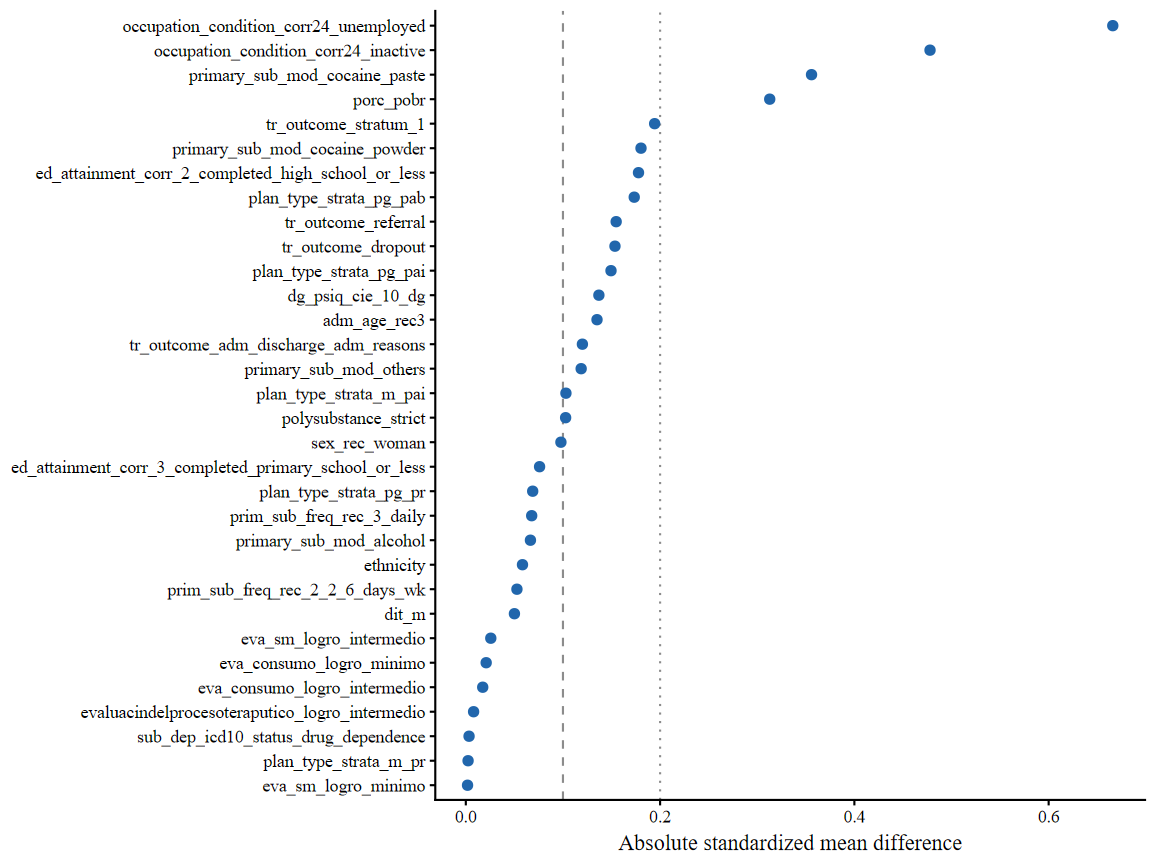

In [28]:
#| label: smd-comparison

cat("\n--- Standardized mean difference comparison ---\n")
cat("Comparing development imputations to external validation cohort.\n")
flush.console()

# Compute SMDs between each development imputation and the external cohort,
# then pool across imputations.
smd <- compute_smd_across_imputations(train_list, external_data, plan_levels)

# Print the 15 largest mean absolute SMDs.
print_table(
  utils::head(smd$summary, 15L),
  "Largest development-versus-external standardized mean differences",
  digits = 3
)

# Compute supplementary SMDs restricted to external patients with at least
# the horizon's worth of potential follow-up.
horizon_smd <- compute_horizon_complete_followup_smd(
  train_list, external_data, plan_levels, HORIZONS
)

# Print the top 5 largest SMDs per horizon.
print_table(
  horizon_smd |>
    dplyr::group_by(horizon_months) |>
    dplyr::slice_max(abs_smd_mean, n = 5, with_ties = FALSE) |>
    dplyr::ungroup(),
  "Supplementary SMD diagnostic among patients with complete potential follow-up",
  digits = 3
)

# Create a dot plot of absolute SMDs for visual inspection of transportability.
smd_plot <- ggplot2::ggplot(
  smd$summary,
  ggplot2::aes(x = stats::reorder(variable, abs_smd_mean), y = abs_smd_mean)
) +
  ggplot2::geom_hline(yintercept = c(0.10, 0.20), linetype = c("dashed", "dotted"), color = "grey55") +
  ggplot2::geom_point(color = "#2166AC", size = 2) +
  ggplot2::coord_flip() +
  ggplot2::labs(x = NULL, y = "Absolute standardized mean difference") +
  ggplot2::theme_classic(base_size = 11, base_family = "serif")

cat("Displaying SMD plot.\n")
flush.console()

print(smd_plot)

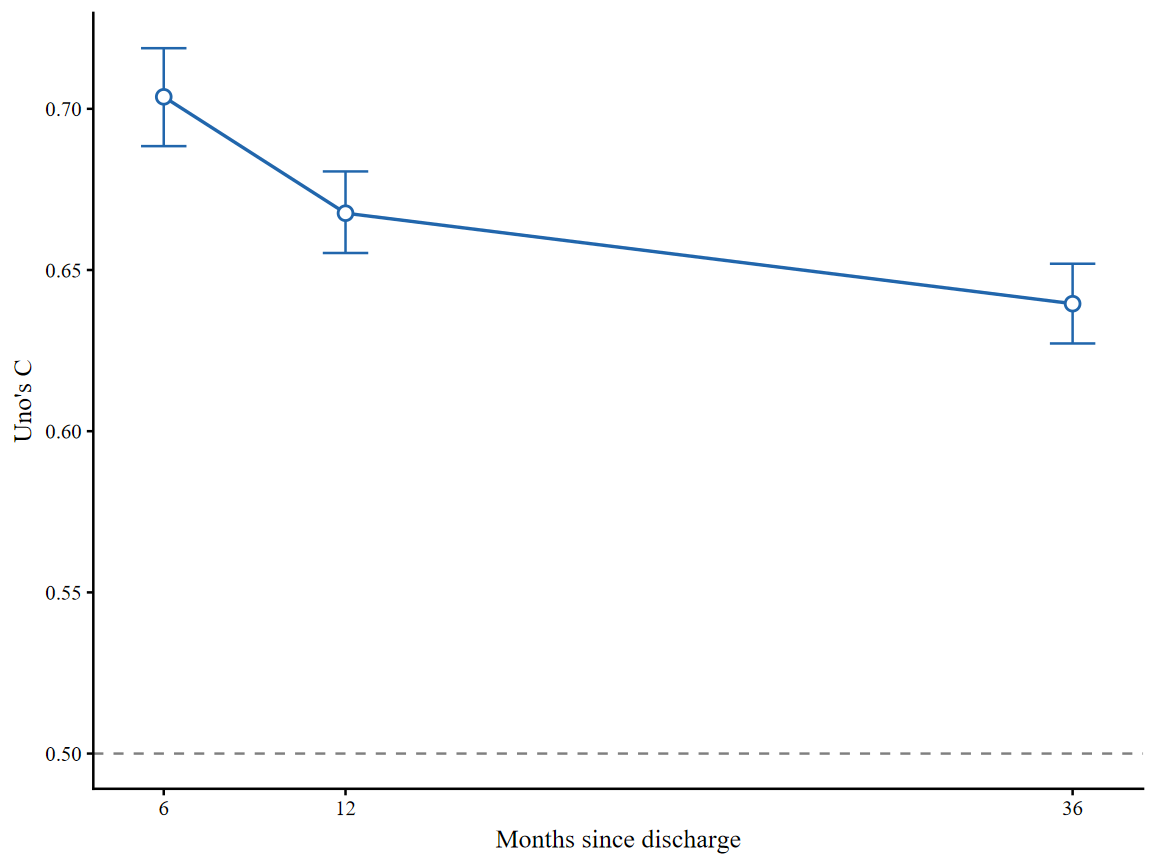

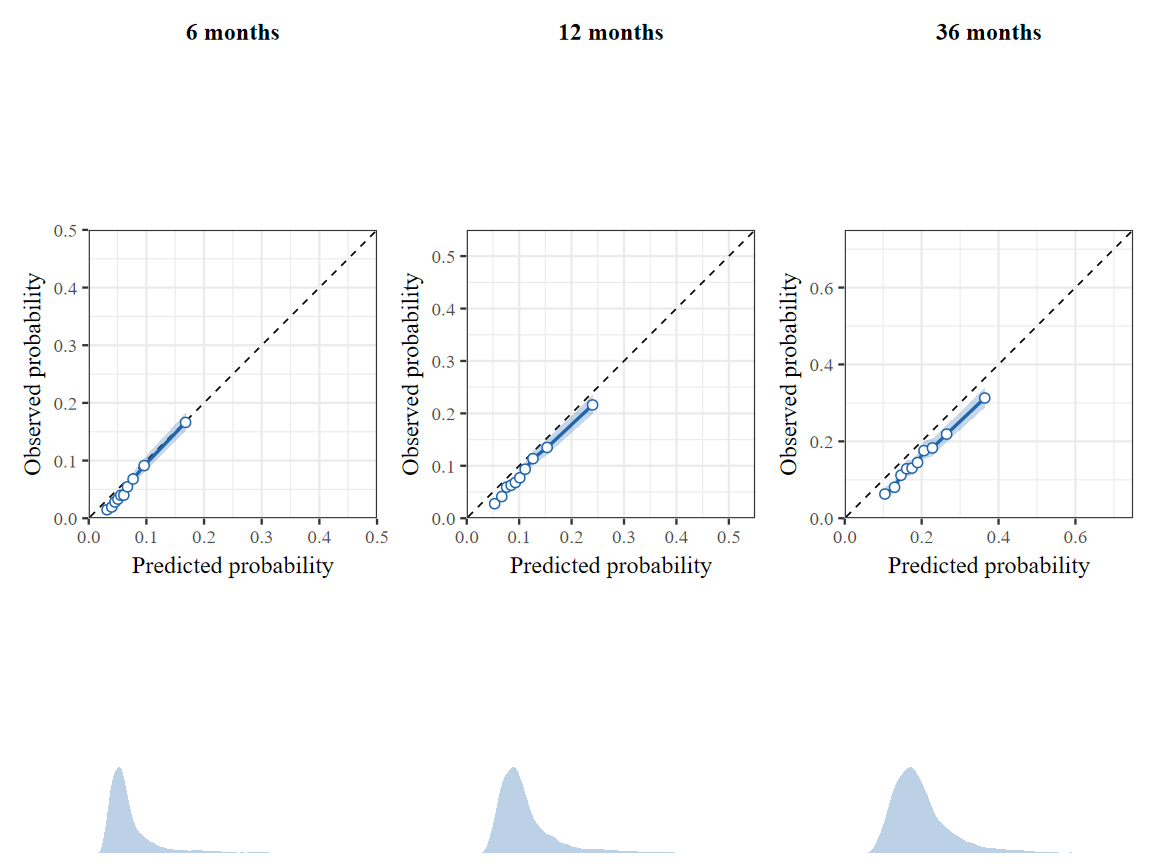

In [29]:
#| label: publication-style-figures
#| fig-width: 12
#| fig-height: 4.5

concordance_plot <- plot_concordance(external_c$summary)
print(concordance_plot)

calibration_panels <- lapply(seq_along(HORIZONS), function(j) {
  horizon <- HORIZONS[[j]]
  create_calibration_panel(
    calibration_curves[calibration_curves$horizon_months == horizon, ],
    external_predictions$horizon$pooled[, j],
    horizon
  )
})
calibration_plot <- patchwork::wrap_plots(calibration_panels, nrow = 1)
print(calibration_plot)

suffix <- if (OFFICIAL_RUN) "full" else "tentative_smoke"
ggplot2::ggsave(file.path(OUTPUT_DIR, paste0("readmission_uno_c_", suffix, ".png")), concordance_plot, width = 7, height = 4.5, dpi = 300)
ggplot2::ggsave(file.path(OUTPUT_DIR, paste0("readmission_calibration_", suffix, ".png")), calibration_plot, width = 12, height = 5, dpi = 300)
ggplot2::ggsave(file.path(OUTPUT_DIR, paste0("readmission_smd_", suffix, ".png")), smd_plot, width = 8, height = 8, dpi = 300)


In [30]:
#| label: save-results

result_bundle <- list(
  created = as.character(Sys.time()),
  official_run = OFFICIAL_RUN,
  config = config,
  input_manifest = input_manifest,
  formula = f_readmit,
  fit_audit = frozen$audit,
  baseline_strata = baseline_strata,
  cohort_flow = external_built$flow,
  source_date_audit = source_date_audit,
  missingness = external_prepared$missingness,
  encoding_audit = external_prepared$category_audit,
  support = support_table,
  c_internal = internal_c$summary,
  c_external = external_c$summary,
  c_within_strata_internal = internal_c_within$summary,
  c_within_strata_external = external_c_within$summary,
  performance_internal = internal_point$table,
  performance_external = performance_table,
  bootstrap_precision = bootstrap_precision,
  calibration_curves_external = calibration_curves,
  brier_curve_external = external_point$brier_curve,
  riley = riley_results,
  events_per_parameter = event_parameter_table,
  smd = smd,
  horizon_complete_followup_smd = horizon_smd,
  stage_times = stage_times,
  mortality_measurement_note = paste(
    "Individual post-2020 death dates were unavailable and were not used to censor external follow-up.",
    "The exact internally death-masked sensitivity requires reconstruction from the pre-censoring source layer."
  )
)

suffix <- if (OFFICIAL_RUN) "full" else "tentative_smoke"
saveRDS(result_bundle, file.path(OUTPUT_DIR, paste0("prediction26_", suffix, ".rds")))

csv_objects <- list(
  config = config,
  input_manifest = input_manifest,
  cohort_flow = external_built$flow,
  source_date_audit = source_date_audit,
  missingness = external_prepared$missingness,
  support = support_table,
  performance_external = performance_table,
  uno_c_within_strata = dplyr::bind_rows(
    dplyr::mutate(internal_c_within$summary, cohort = "Internal holdout"),
    dplyr::mutate(external_c_within$summary, cohort = "External temporal C1")
  ),
  bootstrap_precision = bootstrap_precision,
  calibration_curves_external = calibration_curves,
  riley = riley_results,
  events_per_parameter = event_parameter_table,
  smd_summary = smd$summary,
  smd_detailed = smd$detailed,
  horizon_complete_followup_smd = horizon_smd,
  stage_times = stage_times
)
invisible(Map(function(data, name) {
  utils::write.csv(data, file.path(OUTPUT_DIR, paste0(name, ".csv")), row.names = FALSE, na = "")
}, csv_objects, names(csv_objects)))

output_manifest <- data.frame(
  file = list.files(OUTPUT_DIR, full.names = TRUE),
  size_bytes = file.info(list.files(OUTPUT_DIR, full.names = TRUE))$size
)
print_table(stage_times, "Measured execution time by stage", digits = 2)
print_table(output_manifest, "Output manifest", digits = 0)

if (!OFFICIAL_RUN) {
  cat("\nRESULT STATUS: TENTATIVE SMOKE TEST. Do not cite or transfer these estimates to the manuscript.\n")
}




Table: Measured execution time by stage

|stage                                          | seconds|
|:----------------------------------------------|-------:|
|Load frozen inputs                             |    4.57|
|Build external readmission cohort              |    4.23|
|Create explicit model-ready external data      |    0.14|
|Fit five frozen development models             |    7.87|
|Predict external readmission risk              |    9.82|
|Predict internal holdout risk                  |    9.00|
|External Uno C bootstrap                       |  131.01|
|Internal Uno C point estimates                 |    0.14|
|External calibration, Brier, and IBS bootstrap | 4622.19|
|Riley precision audit for external temporal C1 |  564.39|
|Riley precision audit for internal holdout     |  385.16|


Table: Output manifest

|file                                                                                         | size_bytes|
|:------------------------------------------------------

In [31]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true

message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", getwd()))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

tabla_pkg <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  package,
  loadedversion,
  source
)

tabla_pkg <- tibble::rowid_to_column(tabla_pkg, var = "row_number")

names(tabla_pkg) <- c("Row number", "Package", "Version", "Source")

htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 420px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
      font-size: 70%;
      line-height: 0.75em;
      width: 100%;
    ",
    htmltools::tags$caption(
      style = "
        caption-side: top;
        text-align: left;
        display: block;
        padding: 6px 4px;
        font-size: 120%;
        line-height: 1.2em;
      ",
      htmltools::em("R packages")
    ),
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
        white-space: nowrap;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(tabla_pkg), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                z-index: 2;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(tabla_pkg)), function(i) {
          htmltools::tags$tr(
            lapply(tabla_pkg[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

R library: C:\Users\andre\AppData\Local/R/win-library/4.4
Date: 2026-07-12 20:54:54.374965
Editor context: g:/My Drive/Alvacast/SISTRAT 2023/cons
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/RtmpI3McUK/file6a5c30a92fc5 -V' had status 1


1,cachem,1.1.0,CRAN (R 4.4.1)
2,cli,3.6.4,CRAN (R 4.4.1)
3,devtools,2.4.5,CRAN (R 4.4.1)
4,digest,0.6.37,CRAN (R 4.4.1)
5,dplyr,1.1.4,CRAN (R 4.4.3)
6,ellipsis,0.3.2,CRAN (R 4.4.1)
7,evaluate,1.0.5,CRAN (R 4.4.3)
8,farver,2.1.2,CRAN (R 4.4.1)
9,fastmap,1.2.0,CRAN (R 4.4.1)
10,fs,1.6.5,CRAN (R 4.4.1)
11,generics,0.1.4,CRAN (R 4.4.3)
